# **Important! I reran the codes so the results are slightly different as one of the stock was delisted and I changed it to another stock**
# Installation

In [1]:
# Install required libraries
# !pip install pandas numpy yfinance ta matplotlib seaborn scikit-learn streamlit

# Imports

In [46]:
# Import core libraries and test
import pandas as pd
import numpy as np
import yfinance as yf
import ta  # technical analysis library
from datetime import datetime, timedelta
from scipy.stats import mstats
import os
import warnings
import yfinance as yf
import pandas as pd
from datetime import datetime
import time
import yfinance as yf
import pandas as pd
import time
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import pickle
from sklearn.model_selection import TimeSeriesSplit
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score
)
import joblib
import os

warnings.filterwarnings('ignore')

print(" Environment setup complete")
print(f"Pandas version: {pd.__version__}")
print(f"Numpy version: {np.__version__}")

 Environment setup complete
Pandas version: 3.0.1
Numpy version: 2.2.6


# SGX Stock Universe

In [3]:
# STI (Straits Times Index) Constituents (~30 stocks)
# Source: https://www.sgx.com/indices/products/sti
sti_stocks = {
    # Banks
    'D05.SI': 'DBS Group Holdings',
    'O39.SI': 'OCBC Bank',
    'U11.SI': 'United Overseas Bank',
    
    # Telco & Transport
    'Z74.SI': 'Singtel',
    'C52.SI': 'ComfortDelGro',
    'C6L.SI': 'Singapore Airlines',
    
    # Conglomerates & Industrial
    'BN4.SI': 'Keppel Corporation',
    'U96.SI': 'Sembcorp Industries',
    'S63.SI': 'Singapore Technologies Engineering',
    'F34.SI': 'Wilmar International',
    
    # Property
    '9CI.SI': 'CapitaLand Investment',
    'J69U.SI': 'Mapletree Logistics Trust',
    'ME8U.SI': 'Mapletree Industrial Trust',
    'M44U.SI': 'Mapletree Pan Asia Commercial Trust',
    
    # Others
    'S68.SI': 'SGX',
    'Y92.SI': 'Thai Beverage',
    'BS6.SI': 'YZJ Shipbldg SGD',
    'G13.SI': 'Genting Singapore',
    'H78.SI': 'Hongkong Land Holdings',
    'V03.SI': 'Venture Corporation',
    'U14.SI': 'UOL Group',
    'C09.SI': 'City Developments',
    'N2IU.SI': 'Mapletree North Asia Commercial Trust',
    'D01.SI': 'DFI Retail Group',
    'S58.SI': 'SATS',
    'CC3.SI': 'StarHub',
    'C07.SI': 'Jardine Cycle & Carriage',
    'C38U.SI': 'CapitaLand Ascendas REIT',
    'A17U.SI': 'Ascendas Real Estate Investment Trust',
    'J36.SI': 'Jardine Matheson Holdings'
}

# Additional Growth/Mid-cap Stocks (25 stocks)
growth_stocks = {
    # TECHNOLOGY (5-7 stocks)
    'AWX.SI': 'AEM Holdings',           # Semiconductor equipment
    'U10.SI': 'UOB-Kay Hian',           # Fintech brokerage
    'BVA.SI': 'Frencken Group',         # Electronics manufacturing
    'QES.SI': 'Q&M Dental Group',       # Healthcare tech
    'AIY.SI': 'iFAST Corporation',
    
    # HEALTHCARE (3-5 stocks)
    '1D0.SI': 'Raffles Medical Group',
    'QC7.SI': 'Cordlife Group',
    '5DD.SI': 'Micro-Mechanics Holdings',
    'A50.SI': 'Thomson Medical Group',
    '546.SI': 'Medtecs International Corporation Limited',
    
    # CONSUMER (3-5 stocks)
    'F03.SI': 'Food Empire Holdings',   # F&B growth
    'P34.SI': 'Delfi Limited',
    '1J4.SI': 'Koufu Group',            # Food court operator
    '5OI.SI': 'Japan Foods Holding',
    '42R.SI': 'Jumbo Group Limited',
    'OV8.SI': 'Sheng Siong Group Ltd',
    
    # REITS - GROWTH/MID-CAP (5-8 stocks)
    'K71U.SI': 'Keppel DC REIT',        # Data centers (growth sector)
    'T82U.SI': 'Suntec REIT',
    'AJBU.SI': 'Keppel Infrastructure Trust',
    'CMOU.SI': 'CapitaLand China Trust',
    'C2PU.SI': 'Parkway Life Real Estate Investment Trust',
    
    # INDUSTRIAL (3-5 stocks)
    'E5H.SI': 'Golden Agri-Resources',
    'C41.SI': 'Olam Group',
    'U77.SI': 'Yanlord Land Group',
    'P8Z.SI': 'Bumitama Agri Ltd.',
}

# Combine both lists
sgx_universe = {**sti_stocks, **growth_stocks}

# Convert to DataFrame for easy viewing
universe_df = pd.DataFrame(
    list(sgx_universe.items()), 
    columns=['Ticker', 'Company_Name']
)

print(f" Total stocks defined: {len(sgx_universe)}")
print(f"  - STI stocks: {len(sti_stocks)}")
print(f"  - Growth stocks: {len(growth_stocks)}")
print("\nFirst 10 stocks:")
print(universe_df.head(10))

 Total stocks defined: 55
  - STI stocks: 30
  - Growth stocks: 25

First 10 stocks:
   Ticker                        Company_Name
0  D05.SI                  DBS Group Holdings
1  O39.SI                           OCBC Bank
2  U11.SI                United Overseas Bank
3  Z74.SI                             Singtel
4  C52.SI                       ComfortDelGro
5  C6L.SI                  Singapore Airlines
6  BN4.SI                  Keppel Corporation
7  U96.SI                 Sembcorp Industries
8  S63.SI  Singapore Technologies Engineering
9  F34.SI                Wilmar International


In [4]:
# Create folders to store the data of the stock prices
os.makedirs('data', exist_ok=True)
os.makedirs('data/prices', exist_ok=True)

print(" Folders created: data/prices/")

 Folders created: data/prices/


In [5]:
# Set the date range of the stock prices data we want
start_date = '2020-01-01'
end_date = '2024-12-31'

# Get list of tickers from Step 2
tickers = list(sgx_universe.keys())

print(f"Downloading price data for {len(tickers)} stocks...")
print(f"Date range: {start_date} to {end_date}\n")
print("="*60)

# Storage for downloaded data
price_data = {}
failed_tickers = []
success_count = 0

# Download each stock
for i, ticker in enumerate(tickers, 1):
    try:
        print(f"[{i}/{len(tickers)}] {ticker:12s} ({sgx_universe[ticker]:30s})", end=' ')
        
        # Download using yfinance
        stock = yf.Ticker(ticker)
        df = stock.history(start=start_date, end=end_date)
        
        # Check if data was downloaded
        if len(df) > 0:
            # Rename columns to match architecture spec
            df_clean = pd.DataFrame({
                'Date': df.index,
                'Open': df['Open'],
                'High': df['High'],
                'Low': df['Low'],
                'Price': df['Close'],  # Use 'Close' as 'Price'
                'Vol': df['Volume'],
            })
            
            # Calculate Change%
            df_clean['Change%'] = df_clean['Price'].pct_change() * 100
            
            # Set Date as index
            df_clean.set_index('Date', inplace=True)
            
            # Save to CSV
            ticker_clean = ticker.replace('.SI', '')  # Remove .SI for filename
            filepath = f'data/prices/{ticker_clean}.csv'
            df_clean.to_csv(filepath)
            
            # Store in memory
            price_data[ticker] = df_clean
            success_count += 1
            
            print(f" {len(df_clean)} rows")
        else:
            print(" No data available")
            failed_tickers.append(ticker)
            
        time.sleep(0.5)
        
    except Exception as e:
        print(f" Error: {str(e)[:50]}")
        failed_tickers.append(ticker)

print("="*60)
print(f"\n Successfully downloaded: {success_count}/{len(tickers)} stocks")
print(f" Failed: {len(failed_tickers)} stocks")

if failed_tickers:
    print("\nFailed tickers:")
    for ticker in failed_tickers:
        print(f"  - {ticker}: {sgx_universe[ticker]}")

Date range: 2020-01-01 to 2024-12-31

[1/55] D05.SI       (DBS Group Holdings            )  1255 rows
[2/55] O39.SI       (OCBC Bank                     )  1255 rows
[3/55] U11.SI       (United Overseas Bank          )  1255 rows
[4/55] Z74.SI       (Singtel                       )  1255 rows
[5/55] C52.SI       (ComfortDelGro                 )  1255 rows
[6/55] C6L.SI       (Singapore Airlines            )  1255 rows
[7/55] BN4.SI       (Keppel Corporation            )  1255 rows
[8/55] U96.SI       (Sembcorp Industries           )  1255 rows
[9/55] S63.SI       (Singapore Technologies Engineering)  1255 rows
[10/55] F34.SI       (Wilmar International          )  1255 rows
[11/55] 9CI.SI       (CapitaLand Investment         )  824 rows
[12/55] J69U.SI      (Mapletree Logistics Trust     )  1255 rows
[13/55] ME8U.SI      (Mapletree Industrial Trust    )  1255 rows
[14/55] M44U.SI      (Mapletree Pan Asia Commercial Trust)  1255 rows
[15/55] S68.SI       (SGX                           )

# *Data Validation*

In [6]:
# ============================================
# DATA VALIDATION
# ============================================

print("\n" + "="*60)
print("DATA QUALITY CHECK")
print("="*60)

# Check first 5 stocks in detail
print("\nSample of first 5 stocks:")
for ticker in list(price_data.keys())[:5]:
    df = price_data[ticker]
    missing_pct = (df['Price'].isna().sum() / len(df)) * 100
    
    print(f"\n{ticker} ({sgx_universe[ticker]}):")
    print(f"  - Rows: {len(df)}")
    print(f"  - Date range: {df.index.min().date()} to {df.index.max().date()}")
    print(f"  - Missing data: {missing_pct:.1f}%")
    print(f"  - Latest price: ${df['Price'].iloc[-1]:.2f}")
    
    if missing_pct > 10:
        print(f"     WARNING: More than 10% missing data!")

# Overall statistics
print("\n" + "-"*60)
print("OVERALL STATISTICS:")
print("-"*60)

total_rows = sum(len(df) for df in price_data.values())
avg_rows = total_rows / len(price_data) if price_data else 0

print(f"Total stocks downloaded: {len(price_data)}")
print(f"Total data points: {total_rows:,}")
print(f"Average rows per stock: {avg_rows:.0f}")

# Expected number of trading days (approx 252 per year × 5 years)
expected_days = 252 * 5
print(f"Expected trading days: ~{expected_days}")
print(f"Coverage: {(avg_rows/expected_days)*100:.1f}%")

# Check for stocks with too much missing data
print("\n   Stocks with >10% missing data:")
problematic = []
for ticker, df in price_data.items():
    missing_pct = (df['Price'].isna().sum() / len(df)) * 100
    if missing_pct > 10:
        problematic.append((ticker, missing_pct))
        
if problematic:
    for ticker, pct in problematic:
        print(f"  - {ticker}: {pct:.1f}% missing")
else:
    print("  None ")


DATA QUALITY CHECK

Sample of first 5 stocks:

D05.SI (DBS Group Holdings):
  - Rows: 1255
  - Date range: 2020-01-02 to 2024-12-30
  - Missing data: 0.0%
  - Latest price: $41.33

O39.SI (OCBC Bank):
  - Rows: 1255
  - Date range: 2020-01-02 to 2024-12-30
  - Missing data: 0.0%
  - Latest price: $15.74

U11.SI (United Overseas Bank):
  - Rows: 1255
  - Date range: 2020-01-02 to 2024-12-30
  - Missing data: 0.0%
  - Latest price: $34.11

Z74.SI (Singtel):
  - Rows: 1255
  - Date range: 2020-01-02 to 2024-12-30
  - Missing data: 0.0%
  - Latest price: $2.97

C52.SI (ComfortDelGro):
  - Rows: 1255
  - Date range: 2020-01-02 to 2024-12-30
  - Missing data: 0.0%
  - Latest price: $1.40

------------------------------------------------------------
OVERALL STATISTICS:
------------------------------------------------------------
Total stocks downloaded: 55
Total data points: 68,594
Average rows per stock: 1247
Expected trading days: ~1260
Coverage: 99.0%

   Stocks with >10% missing data:
  

# *Visual Check*

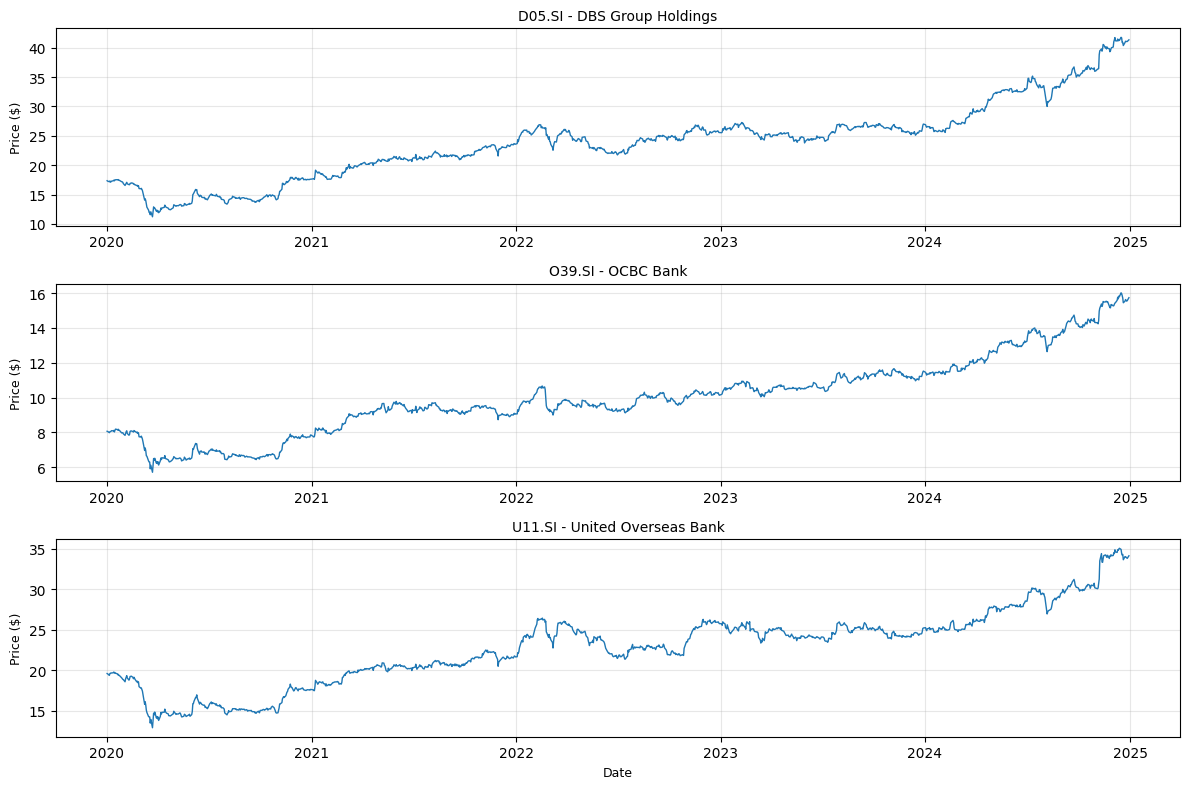

  Sample charts saved to: data/price_sample_charts.png


In [7]:
# ============================================
# VISUAL CHECK
# ============================================

# Plot price chart for first 3 stocks
fig, axes = plt.subplots(3, 1, figsize=(12, 8))

for i, ticker in enumerate(list(price_data.keys())[:3]):
    df = price_data[ticker]
    axes[i].plot(df.index, df['Price'], linewidth=1)
    axes[i].set_title(f"{ticker} - {sgx_universe[ticker]}", fontsize=10)
    axes[i].set_ylabel('Price ($)', fontsize=9)
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('Date', fontsize=9)
plt.tight_layout()
plt.savefig('data/price_sample_charts.png', dpi=100)
plt.show()

print("  Sample charts saved to: data/price_sample_charts.png")



# *Fundamental Data*

In [8]:
# ============================================
# STEP 4: COLLECT FUNDAMENTAL DATA
# ============================================

# Define Fundamental metrics:
fundamental_metrics = [
    'marketCap',           # Market Capitalization
    'trailingPE',          # P/E Ratio
    'trailingEps',         # Earnings Per Share (EPS)
    'revenueGrowth',       # Revenue Growth Rate
    'profitMargins',       # Profit Margin
    'dividendYield',       # Dividend Yield
    'payoutRatio',         # Dividend Payout Ratio
    'debtToEquity',        # Debt-to-Equity Ratio
    'returnOnEquity',      # ROE
    'sector',              # Industry Sector
    'industry',            # Sub-industry
]

print("Fundamental metrics to collect:")
for metric in fundamental_metrics:
    print(f"  - {metric}")

Fundamental metrics to collect:
  - marketCap
  - trailingPE
  - trailingEps
  - revenueGrowth
  - profitMargins
  - dividendYield
  - payoutRatio
  - debtToEquity
  - returnOnEquity
  - sector
  - industry


In [9]:
# Get list of tickers
tickers = list(sgx_universe.keys())

print(f"Collecting fundamental data for {len(tickers)} stocks...")
print("="*60)

# Storage for fundamental data
fundamental_data = []
failed_fundamentals = []

# Download fundamental data for each stock
for i, ticker in enumerate(tickers, 1):
    try:
        print(f"[{i}/{len(tickers)}] {ticker:12s}", end=' ')
        
        # Get stock info using yfinance
        stock = yf.Ticker(ticker)
        info = stock.info
        
        # Extract fundamental metrics
        stock_fundamentals = {
            'Ticker': ticker,
            'Company_Name': sgx_universe[ticker],
            'Market_Cap': info.get('marketCap', None),
            'PE_Ratio': info.get('trailingPE', None),
            'EPS': info.get('trailingEps', None),
            'Revenue_Growth': info.get('revenueGrowth', None),
            'Profit_Margin': info.get('profitMargins', None),
            'Dividend_Yield': info.get('dividendYield', None),
            'Payout_Ratio': info.get('payoutRatio', None),
            'Debt_to_Equity': info.get('debtToEquity', None),
            'ROE': info.get('returnOnEquity', None),
            'Sector': info.get('sector', 'Unknown'),
            'Industry': info.get('industry', 'Unknown'),
        }
        
        fundamental_data.append(stock_fundamentals)
        print(f" Sector: {stock_fundamentals['Sector']}")
        
        # Be nice to the API
        time.sleep(0.5)
        
    except Exception as e:
        print(f" Error: {str(e)[:50]}")
        failed_fundamentals.append(ticker)
        
        # Add empty row so we don't lose the stock
        fundamental_data.append({
            'Ticker': ticker,
            'Company_Name': sgx_universe[ticker],
            'Market_Cap': None,
            'PE_Ratio': None,
            'EPS': None,
            'Revenue_Growth': None,
            'Profit_Margin': None,
            'Dividend_Yield': None,
            'Payout_Ratio': None,
            'Debt_to_Equity': None,
            'ROE': None,
            'Sector': 'Unknown',
            'Industry': 'Unknown',
        })

print("="*60)

# Convert to DataFrame
fundamentals_df = pd.DataFrame(fundamental_data)

# Save to CSV
fundamentals_df.to_csv('data/fundamentals_raw.csv', index=False)

print(f"\n  Fundamental data collected for {len(fundamental_data)} stocks")
print(f" Saved to: data/fundamentals_raw.csv")

if failed_fundamentals:
    print(f"\n   {len(failed_fundamentals)} stocks had errors:")
    for ticker in failed_fundamentals:
        print(f"  - {ticker}")

[1/55] D05.SI        Sector: Financial Services
[2/55] O39.SI        Sector: Financial Services
[3/55] U11.SI        Sector: Financial Services
[4/55] Z74.SI        Sector: Communication Services
[5/55] C52.SI        Sector: Industrials
[6/55] C6L.SI        Sector: Industrials
[7/55] BN4.SI        Sector: Industrials
[8/55] U96.SI        Sector: Utilities
[9/55] S63.SI        Sector: Industrials
[10/55] F34.SI        Sector: Consumer Defensive
[11/55] 9CI.SI        Sector: Real Estate
[12/55] J69U.SI       Sector: Real Estate
[13/55] ME8U.SI       Sector: Real Estate
[14/55] M44U.SI       Sector: Real Estate
[15/55] S68.SI        Sector: Financial Services
[16/55] Y92.SI        Sector: Consumer Defensive
[17/55] BS6.SI        Sector: Industrials
[18/55] G13.SI        Sector: Consumer Cyclical
[19/55] H78.SI        Sector: Real Estate
[20/55] V03.SI        Sector: Technology
[21/55] U14.SI        Sector: Real Estate
[22/55] C09.SI        Sector: Real Estate
[23/55] N2IU.SI       Sector:

In [10]:
# ============================================
# INSPECT FUNDAMENTAL DATA
# ============================================

print("\n" + "="*60)
print("FUNDAMENTAL DATA PREVIEW")
print("="*60)

# Show first 10 rows
print("\nFirst 10 stocks:")
print(fundamentals_df.head(10).to_string())

# Check missing data
print("\n" + "-"*60)
print("MISSING DATA ANALYSIS")
print("-"*60)

missing_summary = fundamentals_df.isnull().sum()
total_stocks = len(fundamentals_df)

print(f"\nTotal stocks: {total_stocks}\n")
for column in fundamentals_df.columns:
    if column not in ['Ticker', 'Company_Name']:
        missing_count = missing_summary[column]
        missing_pct = (missing_count / total_stocks) * 100
        print(f"{column:20s}: {missing_count:2d} missing ({missing_pct:5.1f}%)")

# Check sector distribution
print("\n" + "-"*60)
print("SECTOR DISTRIBUTION")
print("-"*60)

sector_counts = fundamentals_df['Sector'].value_counts()
print(sector_counts)

# Check for completely empty rows
empty_rows = fundamentals_df[fundamentals_df['Market_Cap'].isna() & 
                              fundamentals_df['PE_Ratio'].isna() & 
                              fundamentals_df['ROE'].isna()]

if len(empty_rows) > 0:
    print(f"\n  WARNING: {len(empty_rows)} stocks have NO fundamental data:")
    for idx, row in empty_rows.iterrows():
        print(f"  - {row['Ticker']}: {row['Company_Name']}")


FUNDAMENTAL DATA PREVIEW

First 10 stocks:
   Ticker                        Company_Name    Market_Cap   PE_Ratio   EPS  Revenue_Growth  Profit_Margin  Dividend_Yield  Payout_Ratio  Debt_to_Equity      ROE                  Sector                 Industry
0  D05.SI                  DBS Group Holdings  162877046784  15.026178  3.82          -0.033        0.49450            5.33        0.7461             NaN  0.15875      Financial Services         Banks - Regional
1  O39.SI                           OCBC Bank   95971524608  13.110430  1.63           0.065        0.53208            3.93        0.5031             NaN  0.12198      Financial Services         Banks - Regional
2  U11.SI                United Overseas Bank   61552209920  13.520000  2.75          -0.018        0.39793            3.82        0.6436             NaN  0.09256      Financial Services         Banks - Regional
3  Z74.SI                             Singtel   85879693312  14.081081  0.37           0.009        0.47967 

# *Summary Statistics of Fundamental Data*

In [11]:
# ============================================
# SUMMARY STATISTICS
# ============================================
print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)

# Numeric columns only
numeric_cols = ['Market_Cap', 'PE_Ratio', 'EPS', 'Revenue_Growth', 
                'Profit_Margin', 'Dividend_Yield', 'Payout_Ratio', 
                'Debt_to_Equity', 'ROE']

# Convert all numeric columns to proper numeric type
for col in numeric_cols:
    fundamentals_df[col] = pd.to_numeric(fundamentals_df[col], errors='coerce')

stats_df = fundamentals_df[numeric_cols].describe()
print(stats_df.to_string())

# Highlight extreme values
print("\n" + "-"*60)
print("EXTREME VALUES (Potential Outliers)")
print("-"*60)

# High P/E ratios (>100 might be problematic)
high_pe = fundamentals_df[fundamentals_df['PE_Ratio'].notna() & (fundamentals_df['PE_Ratio'] > 100)]
if len(high_pe) > 0:
    print(f"\nStocks with P/E > 100: ({len(high_pe)} stocks)")
    for idx, row in high_pe.iterrows():
        print(f"  - {row['Ticker']}: P/E = {row['PE_Ratio']:.1f}")
else:
    print("\nNo stocks with P/E > 100")

# Negative ROE (losing money)
negative_roe = fundamentals_df[fundamentals_df['ROE'].notna() & (fundamentals_df['ROE'] < 0)]
if len(negative_roe) > 0:
    print(f"\nStocks with negative ROE: ({len(negative_roe)} stocks)")
    for idx, row in negative_roe.iterrows():
        print(f"  - {row['Ticker']}: ROE = {row['ROE']:.2%}")
else:
    print("\nNo stocks with negative ROE")

# Very high debt (D/E > 200%)
high_debt = fundamentals_df[fundamentals_df['Debt_to_Equity'].notna() & (fundamentals_df['Debt_to_Equity'] > 200)]
if len(high_debt) > 0:
    print(f"\nStocks with D/E > 200%: ({len(high_debt)} stocks)")
    for idx, row in high_debt.iterrows():
        print(f"  - {row['Ticker']}: D/E = {row['Debt_to_Equity']:.1f}%")
else:
    print("\nNo stocks with D/E > 200%")


SUMMARY STATISTICS
         Market_Cap   PE_Ratio        EPS  Revenue_Growth  Profit_Margin  Dividend_Yield  Payout_Ratio  Debt_to_Equity        ROE
count  5.500000e+01  50.000000  55.000000       53.000000      55.000000       50.000000     55.000000       51.000000  54.000000
mean   1.406540e+10  22.649815   0.427091        0.050396       0.228974        3.774400      0.648749       82.084863   0.098829
std    2.781470e+10  18.009167   0.909649        0.154006       0.289921        1.727066      0.647366      117.432465   0.123772
min    1.997391e+07   7.500000  -1.140000       -0.323000      -0.131040        0.320000      0.000000        0.031000  -0.415440
25%    1.480969e+09  13.025862   0.040000       -0.031000       0.044050        2.750000      0.304000       28.706500   0.045502
50%    4.590030e+09  17.438597   0.120000        0.052000       0.115350        3.750000      0.605500       56.730000   0.090010
75%    1.352585e+10  25.830881   0.390000        0.118000       0.3645

# *Sector Classification Dataset*

In [12]:
# ============================================
# CREATE SECTOR CLASSIFICATION DATASET
# ============================================

print("="*60)
print("CREATE SECTOR CLASSIFICATION")
print("="*60)

# Extract sector mapping from fundamentals
sector_mapping = fundamentals_df[['Ticker', 'Sector', 'Industry']].copy()

# Save to CSV
sector_mapping.to_csv('data/sector_classification.csv', index=False)

print(f"\n  Sector classification saved to: data/sector_classification.csv")
print(f"  Total stocks: {len(sector_mapping)}")

# Show sector distribution
print("\nSector Distribution:")
print(sector_mapping['Sector'].value_counts())

# Show sample
print("\nSample of sector mapping:")
print(sector_mapping.head(10))

CREATE SECTOR CLASSIFICATION

  Sector classification saved to: data/sector_classification.csv
  Total stocks: 55

Sector Distribution:
Sector
Real Estate               15
Industrials                9
Consumer Defensive         8
Financial Services         5
Consumer Cyclical          5
Technology                 5
Healthcare                 4
Communication Services     2
Utilities                  1
Basic Materials            1
Name: count, dtype: int64

Sample of sector mapping:
   Ticker                  Sector                 Industry
0  D05.SI      Financial Services         Banks - Regional
1  O39.SI      Financial Services         Banks - Regional
2  U11.SI      Financial Services         Banks - Regional
3  Z74.SI  Communication Services         Telecom Services
4  C52.SI             Industrials                Railroads
5  C6L.SI             Industrials                 Airlines
6  BN4.SI             Industrials            Conglomerates
7  U96.SI               Utilities  Utiliti

# *Data Cleaning & Validation*

In [13]:
# ============================================
# DATA CLEANING & VALIDATION
# ============================================

print("="*60)
print("CLEAN PRICE DATA")
print("="*60)

# Load all price data files
price_files = [f for f in os.listdir('data/prices/') if f.endswith('.csv')]
print(f"Found {len(price_files)} price data files\n")

cleaned_price_data = {}
stocks_to_remove = []

for i, filename in enumerate(price_files, 1):
    ticker = filename.replace('.csv', '') + '.SI'
    filepath = f'data/prices/{filename}'
    
    print(f"[{i}/{len(price_files)}] Cleaning {ticker}...", end=' ')
    
    try:
        # 1. Load CSV into pandas DataFrame
        df = pd.read_csv(filepath)
        
        # 2. Convert Date column to datetime
        df['Date'] = pd.to_datetime(df['Date'])
        
        # 3. Set Date as index
        df.set_index('Date', inplace=True)
        
        # 4. Sort by date ascending
        df.sort_index(inplace=True)
        
        # 5. Check for missing values
        missing_price = df['Price'].isna().sum()
        missing_pct = (missing_price / len(df)) * 100
        
        # 6. Handle missing values - Forward fill
        if missing_pct > 0 and missing_pct <= 10:
            df['Price'].fillna(method='ffill', inplace=True)
            df['Open'].fillna(method='ffill', inplace=True)
            df['High'].fillna(method='ffill', inplace=True)
            df['Low'].fillna(method='ffill', inplace=True)
            df['Vol'].fillna(0, inplace=True)  # Fill volume with 0 if missing
            print(f"  ({missing_pct:.1f}% missing - filled)")
        
        # 7. Remove stocks with >10% missing data
        elif missing_pct > 10:
            print(f"  REMOVED ({missing_pct:.1f}% missing)")
            stocks_to_remove.append(ticker)
            continue
        else:
            print(f"  (no missing data)")
        
        # 8. Recalculate Change% after filling
        df['Change%'] = df['Price'].pct_change() * 100
        
        # Store cleaned data
        cleaned_price_data[ticker] = df
        
        # Save cleaned version
        df.to_csv(filepath)  # Overwrite original file with cleaned version
        
    except Exception as e:
        print(f"  ERROR: {str(e)[:50]}")
        stocks_to_remove.append(ticker)

print("\n" + "="*60)
print(f"  Cleaned: {len(cleaned_price_data)} stocks")
print(f"  Removed: {len(stocks_to_remove)} stocks")

if stocks_to_remove:
    print("\nRemoved stocks (>10% missing):")
    for ticker in stocks_to_remove:
        print(f"  - {ticker}")

CLEAN PRICE DATA
Found 56 price data files

[1/56] Cleaning 1D0.SI...   (no missing data)
[2/56] Cleaning 1J4.SI...   (no missing data)
[3/56] Cleaning 42R.SI...   (no missing data)
[4/56] Cleaning 546.SI...   (no missing data)
[5/56] Cleaning 5DD.SI...   (no missing data)
[6/56] Cleaning 5OI.SI...   (no missing data)
[7/56] Cleaning 9CI.SI...   (no missing data)
[8/56] Cleaning A17U.SI...   (no missing data)
[9/56] Cleaning A50.SI...   (no missing data)
[10/56] Cleaning AIY.SI...   (no missing data)
[11/56] Cleaning AJBU.SI...   (no missing data)
[12/56] Cleaning AWX.SI...   (no missing data)
[13/56] Cleaning BN4.SI...   (no missing data)
[14/56] Cleaning BS6.SI...   (no missing data)
[15/56] Cleaning BVA.SI...   (no missing data)
[16/56] Cleaning C07.SI...   (no missing data)
[17/56] Cleaning C09.SI...   (no missing data)
[18/56] Cleaning C2PU.SI...   (no missing data)
[19/56] Cleaning C38U.SI...   (no missing data)
[20/56] Cleaning C41.SI...   (no missing data)
[21/56] Cleaning C52.

In [14]:
# ============================================
# CLEAN FUNDAMENTAL DATA
# ============================================

print("\n" + "="*60)
print("CLEAN FUNDAMENTAL DATA")
print("="*60)

# Calculate missing percentage per stock
numeric_cols = ['Market_Cap', 'PE_Ratio', 'EPS', 'Revenue_Growth', 
                'Profit_Margin', 'Dividend_Yield', 'Payout_Ratio', 
                'Debt_to_Equity', 'ROE']

fundamentals_df['Missing_Pct'] = (fundamentals_df[numeric_cols].isna().sum(axis=1) / len(numeric_cols)) * 100

print("\nMissing data per stock:")
print(fundamentals_df[['Ticker', 'Company_Name', 'Missing_Pct']].sort_values('Missing_Pct', ascending=False).head(10))

# Step 1: Drop stocks with >30% missing fundamental data
threshold = 30
stocks_to_drop = fundamentals_df[fundamentals_df['Missing_Pct'] > threshold]

print(f"\n   Stocks with >{threshold}% missing data: {len(stocks_to_drop)}")
if len(stocks_to_drop) > 0:
    for idx, row in stocks_to_drop.iterrows():
        print(f"  - {row['Ticker']}: {row['Missing_Pct']:.1f}% missing")
    
    # Remove them
    fundamentals_clean = fundamentals_df[fundamentals_df['Missing_Pct'] <= threshold].copy()
    print(f"\n  Removed {len(stocks_to_drop)} stocks")
else:
    fundamentals_clean = fundamentals_df.copy()
    print("\n  No stocks need to be removed")

print(f"  Remaining stocks: {len(fundamentals_clean)}")

# Step 2: Median imputation by sector for remaining missing values
print("\n" + "-"*60)
print("Performing sector-median imputation...")
print("-"*60)

for col in numeric_cols:
    missing_before = fundamentals_clean[col].isna().sum()
    
    if missing_before > 0:
        # Calculate median by sector
        sector_medians = fundamentals_clean.groupby('Sector')[col].median()
        
        # Fill missing values with sector median
        for sector in fundamentals_clean['Sector'].unique():
            mask = (fundamentals_clean['Sector'] == sector) & (fundamentals_clean[col].isna())
            if mask.any() and sector in sector_medians:
                fundamentals_clean.loc[mask, col] = sector_medians[sector]
        
        missing_after = fundamentals_clean[col].isna().sum()
        print(f"{col:20s}: {missing_before:2d} → {missing_after:2d} missing")

# Step 3: Check if any missing values remain
remaining_missing = fundamentals_clean[numeric_cols].isna().sum().sum()
if remaining_missing > 0:
    print(f"\n   Warning: {remaining_missing} missing values remain")
    print("These will be handled in feature engineering (forward fill or drop)")
else:
    print("\n  All missing values imputed successfully")

# Save cleaned fundamentals
fundamentals_clean.to_csv('data/fundamentals_clean.csv', index=False)
print(f"\n  Saved to: data/fundamentals_clean.csv")


CLEAN FUNDAMENTAL DATA

Missing data per stock:
     Ticker                               Company_Name  Missing_Pct
43   5OI.SI                        Japan Foods Holding    22.222222
53   U77.SI                         Yanlord Land Group    22.222222
38   A50.SI                      Thomson Medical Group    22.222222
39   546.SI  Medtecs International Corporation Limited    22.222222
0    D05.SI                         DBS Group Holdings    11.111111
1    O39.SI                                  OCBC Bank    11.111111
2    U11.SI                       United Overseas Bank    11.111111
3    Z74.SI                                    Singtel    11.111111
49  CMOU.SI                     CapitaLand China Trust    11.111111
33   QES.SI                           Q&M Dental Group    11.111111

   Stocks with >30% missing data: 0

  No stocks need to be removed
  Remaining stocks: 55

------------------------------------------------------------
Performing sector-median imputation...
----------

In [15]:
# ============================================
# HANDLE OUTLIERS
# ============================================

print("\n" + "="*60)
print("OUTLIER TREATMENT (WINSORIZATION)")
print("="*60)

from scipy.stats import mstats

# Columns to winsorize (especially ratio-based features)
winsorize_cols = ['PE_Ratio', 'Debt_to_Equity', 'Payout_Ratio']

print("\nWinsorizing extreme values at 1st and 99th percentiles...\n")

for col in winsorize_cols:
    if col in fundamentals_clean.columns:
        # Get values before winsorization
        before_min = fundamentals_clean[col].min()
        before_max = fundamentals_clean[col].max()
        
        # Winsorize at 1st and 99th percentile
        # This caps extreme values without removing them
        winsorized = mstats.winsorize(fundamentals_clean[col].dropna(), 
                                       limits=[0.01, 0.01])  # 1% from each end
        
        # Update the DataFrame
        non_na_mask = fundamentals_clean[col].notna()
        fundamentals_clean.loc[non_na_mask, col] = winsorized
        
        # Get values after winsorization
        after_min = fundamentals_clean[col].min()
        after_max = fundamentals_clean[col].max()
        
        print(f"{col:20s}:")
        print(f"  Before: min={before_min:8.2f}, max={before_max:8.2f}")
        print(f"  After:  min={after_min:8.2f}, max={after_max:8.2f}")

# Save final cleaned fundamentals
fundamentals_clean.to_csv('data/fundamentals_clean.csv', index=False)
print(f"\n  Final cleaned fundamentals saved")


OUTLIER TREATMENT (WINSORIZATION)

Winsorizing extreme values at 1st and 99th percentiles...

PE_Ratio            :
  Before: min=    7.50, max=   92.67
  After:  min=    7.50, max=   92.67
Debt_to_Equity      :
  Before: min=    0.03, max=  799.56
  After:  min=    0.03, max=  799.56
Payout_Ratio        :
  Before: min=    0.00, max=    4.14
  After:  min=    0.00, max=    4.14

  Final cleaned fundamentals saved


In [16]:
# ============================================
# SYNCHRONIZE DATASETS
# ============================================

print("\n" + "="*60)
print("SYNCHRONIZE PRICE & FUNDAMENTAL DATA")
print("="*60)

# Get tickers from cleaned price data
price_tickers = set(cleaned_price_data.keys())

# Get tickers from cleaned fundamentals
fundamental_tickers = set(fundamentals_clean['Ticker'].values)

# Find discrepancies
only_in_price = price_tickers - fundamental_tickers
only_in_fundamentals = fundamental_tickers - price_tickers

print(f"\nStocks in price data: {len(price_tickers)}")
print(f"Stocks in fundamental data: {len(fundamental_tickers)}")

if only_in_price:
    print(f"\n   {len(only_in_price)} stocks only in price data:")
    for ticker in only_in_price:
        print(f"  - {ticker}")
    # Remove from price data
    for ticker in only_in_price:
        del cleaned_price_data[ticker]

if only_in_fundamentals:
    print(f"\n   {len(only_in_fundamentals)} stocks only in fundamental data:")
    for ticker in only_in_fundamentals:
        print(f"  - {ticker}")
    # Remove from fundamentals
    fundamentals_clean = fundamentals_clean[~fundamentals_clean['Ticker'].isin(only_in_fundamentals)]

# Final synchronized dataset
final_tickers = price_tickers.intersection(fundamental_tickers)
print(f"\n  Final synchronized stock universe: {len(final_tickers)} stocks")

# Save final stock list
final_universe = fundamentals_clean[['Ticker', 'Company_Name', 'Sector']].copy()
final_universe.to_csv('data/stock_universe_clean.csv', index=False)
print(f"  Saved to: data/stock_universe_clean.csv")



SYNCHRONIZE PRICE & FUNDAMENTAL DATA

Stocks in price data: 56
Stocks in fundamental data: 55

   1 stocks only in price data:
  - M04.SI

  Final synchronized stock universe: 55 stocks
  Saved to: data/stock_universe_clean.csv


In [17]:
# ============================================
# FINAL VALIDATION
# ============================================

print("\n" + "="*60)
print("FINAL VALIDATION CHECK")
print("="*60)

print(f"\n Total stocks in final universe: {len(final_tickers)}")
print(f" Price data files: {len(cleaned_price_data)}")
print(f" Fundamental data rows: {len(fundamentals_clean)}")

# Check date ranges
sample_ticker = list(final_tickers)[0]
sample_df = cleaned_price_data[sample_ticker]
print(f"\nPrice data date range:")
print(f"  Start: {sample_df.index.min().date()}")
print(f"  End: {sample_df.index.max().date()}")
print(f"  Total days: {len(sample_df)}")

# Check missing data
print(f"\nMissing data in fundamentals:")
print(fundamentals_clean[numeric_cols].isna().sum())


FINAL VALIDATION CHECK

 Total stocks in final universe: 55
 Price data files: 55
 Fundamental data rows: 55

Price data date range:
  Start: 2020-01-02
  End: 2024-12-30
  Total days: 1255

Missing data in fundamentals:
Market_Cap        0
PE_Ratio          0
EPS               0
Revenue_Growth    1
Profit_Margin     0
Dividend_Yield    0
Payout_Ratio      0
Debt_to_Equity    1
ROE               0
dtype: int64


# *Feature Engineering*

In [18]:
# ============================================
# FEATURE ENGINEERING - TECHNICAL INDICATORS
# ============================================

print("="*60)
print("FEATURE ENGINEERING - TECHNICAL INDICATORS")
print("="*60)

# Load cleaned stock universe
stock_universe = pd.read_csv('data/stock_universe_clean.csv')
tickers = stock_universe['Ticker'].tolist()

print(f"\nProcessing {len(tickers)} stocks for feature engineering...\n")

# Storage for engineered features
engineered_features = {}

FEATURE ENGINEERING - TECHNICAL INDICATORS

Processing 55 stocks for feature engineering...



In [19]:
# ============================================
# CALCULATE TECHNICAL FEATURES
# ============================================

for i, ticker in enumerate(tickers, 1):
    print(f"[{i}/{len(tickers)}] Processing {ticker}...", end=' ')
    
    try:
        # Load price data
        ticker_clean = ticker.replace('.SI', '')
        filepath = f'data/prices/{ticker_clean}.csv'
        df = pd.read_csv(filepath, parse_dates=['Date'], index_col='Date')
        
        # Make a copy for feature engineering
        df_features = df.copy()
        
        # ============================================
        # 1. RETURN-BASED FEATURES
        # ============================================
        
        # 1-month return (approximately 21 trading days)
        df_features['Return_1M'] = df_features['Price'].pct_change(periods=21)
        
        # 3-month return (approximately 63 trading days)
        df_features['Return_3M'] = df_features['Price'].pct_change(periods=63)
        
        # 6-month return (approximately 126 trading days)
        df_features['Return_6M'] = df_features['Price'].pct_change(periods=126)
        
        # 1-year return (approximately 252 trading days)
        df_features['Return_1Y'] = df_features['Price'].pct_change(periods=252)
        
        # Annualized volatility (std dev of daily returns × √252)
        daily_returns = df_features['Price'].pct_change()
        df_features['Volatility'] = daily_returns.rolling(window=252).std() * np.sqrt(252)
        
        # ============================================
        # 2. MOMENTUM INDICATORS
        # ============================================
        
        # RSI (Relative Strength Index) - 14 day
        df_features['RSI_14'] = ta.momentum.RSIIndicator(
            close=df_features['Price'], 
            window=14
        ).rsi()
        
        # 50-day Simple Moving Average
        df_features['SMA_50'] = ta.trend.SMAIndicator(
            close=df_features['Price'], 
            window=50
        ).sma_indicator()
        
        # 200-day Simple Moving Average
        df_features['SMA_200'] = ta.trend.SMAIndicator(
            close=df_features['Price'], 
            window=200
        ).sma_indicator()
        
        # MA ratios (Current Price / MA)
        df_features['Price_to_SMA50'] = df_features['Price'] / df_features['SMA_50']
        df_features['Price_to_SMA200'] = df_features['Price'] / df_features['SMA_200']
        
        # ============================================
        # 3. VOLUME FEATURES
        # ============================================
        
        # Average daily volume (3-month = 63 days)
        df_features['Avg_Volume_3M'] = df_features['Vol'].rolling(window=63).mean()
        
        # Volume trend (current volume vs 3-month average)
        df_features['Volume_Trend'] = df_features['Vol'] / df_features['Avg_Volume_3M']
        
        # ============================================
        # 4. RISK METRICS
        # ============================================
        
        # Maximum drawdown (past 1 year = 252 days)
        def calculate_max_drawdown(prices, window=252):
            """Calculate maximum drawdown over rolling window"""
            rolling_max = prices.rolling(window=window, min_periods=1).max()
            drawdown = (prices - rolling_max) / rolling_max
            return drawdown
        
        df_features['Max_Drawdown'] = calculate_max_drawdown(df_features['Price'])
        
        # Sharpe ratio (annualized) - assuming risk-free rate = 0 for simplicity
        # Risk-free rate = 0
        mean_return = daily_returns.rolling(window=252).mean()
        std_return = daily_returns.rolling(window=252).std()
        df_features['Sharpe_Ratio'] = (mean_return * 252) / (std_return * np.sqrt(252))
        
        # Replace infinite values with NaN
        df_features['Sharpe_Ratio'].replace([np.inf, -np.inf], np.nan, inplace=True)
        
        # Store engineered features
        engineered_features[ticker] = df_features
        
        print(f" {len(df_features.columns)} features")
        
    except Exception as e:
        print(f" Error: {str(e)[:50]}")

print("\n" + "="*60)
print(f" Feature engineering complete for {len(engineered_features)} stocks")

[1/55] Processing D05.SI...  20 features
[2/55] Processing O39.SI...  20 features
[3/55] Processing U11.SI...  20 features
[4/55] Processing Z74.SI...  20 features
[5/55] Processing C52.SI...  20 features
[6/55] Processing C6L.SI...  20 features
[7/55] Processing BN4.SI...  20 features
[8/55] Processing U96.SI...  20 features
[9/55] Processing S63.SI...  20 features
[10/55] Processing F34.SI...  20 features
[11/55] Processing 9CI.SI...  20 features
[12/55] Processing J69U.SI...  20 features
[13/55] Processing ME8U.SI...  20 features
[14/55] Processing M44U.SI...  20 features
[15/55] Processing S68.SI...  20 features
[16/55] Processing Y92.SI...  20 features
[17/55] Processing BS6.SI...  20 features
[18/55] Processing G13.SI...  20 features
[19/55] Processing H78.SI...  20 features
[20/55] Processing V03.SI...  20 features
[21/55] Processing U14.SI...  20 features
[22/55] Processing C09.SI...  20 features
[23/55] Processing N2IU.SI...  20 features
[24/55] Processing D01.SI...  20 featur

In [20]:
# ============================================
# SAVE ENGINEERED FEATURES
# ============================================

print("\n" + "="*60)
print("SAVING ENGINEERED FEATURES")
print("="*60)

# Create directory for engineered features
os.makedirs('data/engineered', exist_ok=True)

# Save each stock's features as CSV
for ticker, df in engineered_features.items():
    ticker_clean = ticker.replace('.SI', '')
    filepath = f'data/engineered/{ticker_clean}.csv'
    df.to_csv(filepath)

print(f"\n Saved {len(engineered_features)} feature files to: data/engineered/")

# Save list of feature columns for reference
sample_ticker = list(engineered_features.keys())[0]
feature_columns = engineered_features[sample_ticker].columns.tolist()

feature_list_df = pd.DataFrame({'Feature': feature_columns})
feature_list_df.to_csv('data/feature_list.csv', index=False)

print(f" Feature list saved to: data/feature_list.csv")
print(f" Total features per stock: {len(feature_columns)}")


SAVING ENGINEERED FEATURES

 Saved 55 feature files to: data/engineered/
 Feature list saved to: data/feature_list.csv
 Total features per stock: 20


In [21]:
# ============================================
# VALIDATE ENGINEERED FEATURES
# ============================================

print("\n" + "="*60)
print("FEATURE VALIDATION")
print("="*60)

# Pick a sample stock to inspect
sample_ticker = tickers[0]
sample_df = engineered_features[sample_ticker]

print(f"\nSample stock: {sample_ticker}")
print(f"Total rows: {len(sample_df)}")
print(f"Total columns: {len(sample_df.columns)}")

# List all features
print("\nAll features:")
for i, col in enumerate(sample_df.columns, 1):
    print(f"  {i:2d}. {col}")

# Check for missing values in engineered features
print("\n" + "-"*60)
print("Missing values in new features:")
print("-"*60)

new_features = ['Return_1M', 'Return_3M', 'Return_6M', 'Return_1Y', 
                'Volatility', 'RSI_14', 'SMA_50', 'SMA_200', 
                'Price_to_SMA50', 'Price_to_SMA200', 
                'Avg_Volume_3M', 'Volume_Trend', 
                'Max_Drawdown', 'Sharpe_Ratio']

for feature in new_features:
    if feature in sample_df.columns:
        missing_count = sample_df[feature].isna().sum()
        missing_pct = (missing_count / len(sample_df)) * 100
        print(f"{feature:20s}: {missing_count:4d} missing ({missing_pct:5.1f}%)")

# Show sample data (most recent 10 rows)
print("\n" + "-"*60)
print("Sample of engineered features (most recent 10 rows):")
print("-"*60)

cols_to_show = ['Price', 'Return_1M', 'Return_6M', 'Volatility', 
                'RSI_14', 'Price_to_SMA50', 'Max_Drawdown']
print(sample_df[cols_to_show].tail(10).to_string())

# Summary statistics
print("\n" + "-"*60)
print("Summary statistics of engineered features:")
print("-"*60)

print(sample_df[new_features].describe().to_string())


FEATURE VALIDATION

Sample stock: D05.SI
Total rows: 1255
Total columns: 20

All features:
   1. Open
   2. High
   3. Low
   4. Price
   5. Vol
   6. Change%
   7. Return_1M
   8. Return_3M
   9. Return_6M
  10. Return_1Y
  11. Volatility
  12. RSI_14
  13. SMA_50
  14. SMA_200
  15. Price_to_SMA50
  16. Price_to_SMA200
  17. Avg_Volume_3M
  18. Volume_Trend
  19. Max_Drawdown
  20. Sharpe_Ratio

------------------------------------------------------------
Missing values in new features:
------------------------------------------------------------
Return_1M           :   21 missing (  1.7%)
Return_3M           :   63 missing (  5.0%)
Return_6M           :  126 missing ( 10.0%)
Return_1Y           :  252 missing ( 20.1%)
Volatility          :  252 missing ( 20.1%)
RSI_14              :   13 missing (  1.0%)
SMA_50              :   49 missing (  3.9%)
SMA_200             :  199 missing ( 15.9%)
Price_to_SMA50      :   49 missing (  3.9%)
Price_to_SMA200     :  199 missing ( 15.9%)
Avg_


CREATING SAMPLE VISUALIZATIONS


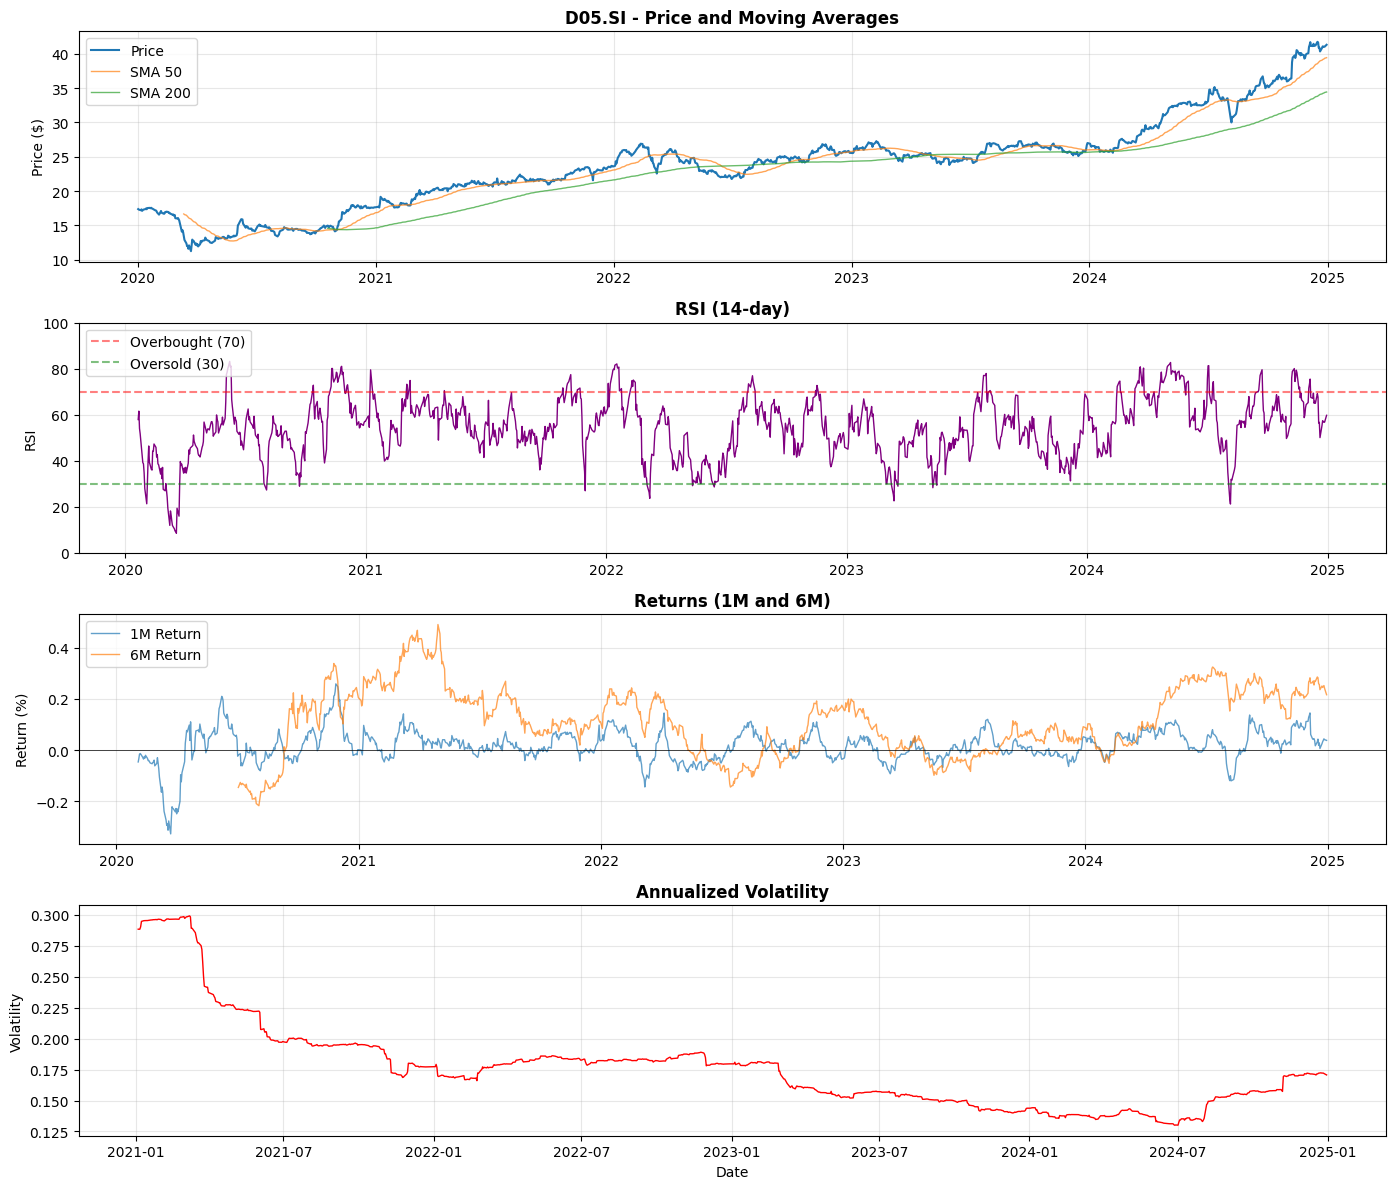


 Visualization saved to: data/sample_features_visualization.png


In [22]:
# ============================================
# VISUAL VALIDATION
# ============================================

print("\n" + "="*60)
print("CREATING SAMPLE VISUALIZATIONS")
print("="*60)

# Plot sample stock with features
sample_ticker = tickers[0]
sample_df = engineered_features[sample_ticker]

fig, axes = plt.subplots(4, 1, figsize=(14, 12))

# Plot 1: Price with Moving Averages
ax1 = axes[0]
ax1.plot(sample_df.index, sample_df['Price'], label='Price', linewidth=1.5)
ax1.plot(sample_df.index, sample_df['SMA_50'], label='SMA 50', alpha=0.7, linewidth=1)
ax1.plot(sample_df.index, sample_df['SMA_200'], label='SMA 200', alpha=0.7, linewidth=1)
ax1.set_title(f'{sample_ticker} - Price and Moving Averages', fontsize=12, fontweight='bold')
ax1.set_ylabel('Price ($)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Plot 2: RSI
ax2 = axes[1]
ax2.plot(sample_df.index, sample_df['RSI_14'], linewidth=1, color='purple')
ax2.axhline(y=70, color='r', linestyle='--', alpha=0.5, label='Overbought (70)')
ax2.axhline(y=30, color='g', linestyle='--', alpha=0.5, label='Oversold (30)')
ax2.set_title('RSI (14-day)', fontsize=12, fontweight='bold')
ax2.set_ylabel('RSI')
ax2.set_ylim(0, 100)
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

# Plot 3: Returns
ax3 = axes[2]
ax3.plot(sample_df.index, sample_df['Return_1M'], label='1M Return', linewidth=1, alpha=0.7)
ax3.plot(sample_df.index, sample_df['Return_6M'], label='6M Return', linewidth=1, alpha=0.7)
ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax3.set_title('Returns (1M and 6M)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Return (%)')
ax3.legend(loc='upper left')
ax3.grid(True, alpha=0.3)

# Plot 4: Volatility
ax4 = axes[3]
ax4.plot(sample_df.index, sample_df['Volatility'], linewidth=1, color='red')
ax4.set_title('Annualized Volatility', fontsize=12, fontweight='bold')
ax4.set_ylabel('Volatility')
ax4.set_xlabel('Date')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data/sample_features_visualization.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n Visualization saved to: data/sample_features_visualization.png")


# *Combining Technical and Fundamental features*

In [23]:
# ============================================
# FEATURE ENGINEERING - FUNDAMENTAL FEATURES
# ============================================


print("="*60)
print("COMBINE TECHNICAL + FUNDAMENTAL FEATURES")
print("="*60)

# Load cleaned fundamental data
fundamentals = pd.read_csv('data/fundamentals_clean.csv')
print(f"\n Loaded fundamental data: {len(fundamentals)} stocks")

# Load sector classification
sectors = pd.read_csv('data/sector_classification.csv')
print(f" Loaded sector classification: {len(sectors)} stocks")

# Get list of stocks with engineered features
engineered_files = [f for f in os.listdir('data/engineered/') if f.endswith('.csv')]
print(f" Found {len(engineered_files)} engineered feature files")

print("\nFundamental features to merge:")
fundamental_cols = ['Market_Cap', 'PE_Ratio', 'EPS', 'Revenue_Growth', 
                    'Profit_Margin', 'Dividend_Yield', 'Payout_Ratio', 
                    'Debt_to_Equity', 'ROE']
for col in fundamental_cols:
    print(f"  - {col}")

COMBINE TECHNICAL + FUNDAMENTAL FEATURES

 Loaded fundamental data: 55 stocks
 Loaded sector classification: 55 stocks
 Found 56 engineered feature files

Fundamental features to merge:
  - Market_Cap
  - PE_Ratio
  - EPS
  - Revenue_Growth
  - Profit_Margin
  - Dividend_Yield
  - Payout_Ratio
  - Debt_to_Equity
  - ROE


In [24]:
# ============================================
# MERGE TECHNICAL + FUNDAMENTAL FEATURES
# ============================================

print("\n" + "="*60)
print("MERGING FEATURES FOR EACH STOCK")
print("="*60)

# Storage for combined features
combined_features = {}
merge_errors = []

for i, filename in enumerate(engineered_files, 1):
    ticker = filename.replace('.csv', '') + '.SI'
    
    print(f"[{i}/{len(engineered_files)}] Processing {ticker}...", end=' ')
    
    try:
        # 1. Load technical features
        filepath = f'data/engineered/{filename}'
        df_technical = pd.read_csv(filepath, parse_dates=['Date'], index_col='Date')
        
        # 2. Get fundamental data for this stock
        stock_fundamentals = fundamentals[fundamentals['Ticker'] == ticker]
        
        if len(stock_fundamentals) == 0:
            print(f" No fundamental data found")
            merge_errors.append(ticker)
            continue
        
        # Extract fundamental values (same for all dates)
        fund_row = stock_fundamentals.iloc[0]
        
        # 3. Add fundamental features as columns (constant for all dates)
        df_technical['Market_Cap'] = fund_row['Market_Cap']
        df_technical['PE_Ratio'] = fund_row['PE_Ratio']
        df_technical['EPS'] = fund_row['EPS']
        df_technical['Revenue_Growth'] = fund_row['Revenue_Growth']
        df_technical['Profit_Margin'] = fund_row['Profit_Margin']
        df_technical['Dividend_Yield'] = fund_row['Dividend_Yield']
        df_technical['Payout_Ratio'] = fund_row['Payout_Ratio']
        df_technical['Debt_to_Equity'] = fund_row['Debt_to_Equity']
        df_technical['ROE'] = fund_row['ROE']
        
        # 4. Add sector information
        df_technical['Sector'] = fund_row['Sector']
        df_technical['Industry'] = fund_row['Industry']
        
        # 5. Add ticker as a column for reference
        df_technical['Ticker'] = ticker
        
        # Store combined features
        combined_features[ticker] = df_technical
        
        total_features = len(df_technical.columns)
        print(f" {total_features} total features")
        
    except Exception as e:
        print(f" Error: {str(e)[:50]}")
        merge_errors.append(ticker)

print("\n" + "="*60)
print(f" Successfully merged: {len(combined_features)} stocks")
print(f" Errors: {len(merge_errors)} stocks")

if merge_errors:
    print("\nStocks with merge errors:")
    for ticker in merge_errors:
        print(f"  - {ticker}")


MERGING FEATURES FOR EACH STOCK
[1/56] Processing 1D0.SI...  32 total features
[2/56] Processing 1J4.SI...  32 total features
[3/56] Processing 42R.SI...  32 total features
[4/56] Processing 546.SI...  32 total features
[5/56] Processing 5DD.SI...  32 total features
[6/56] Processing 5OI.SI...  32 total features
[7/56] Processing 9CI.SI...  32 total features
[8/56] Processing A17U.SI...  32 total features
[9/56] Processing A50.SI...  32 total features
[10/56] Processing AIY.SI...  32 total features
[11/56] Processing AJBU.SI...  32 total features
[12/56] Processing AWX.SI...  32 total features
[13/56] Processing BN4.SI...  32 total features
[14/56] Processing BS6.SI...  32 total features
[15/56] Processing BVA.SI...  32 total features
[16/56] Processing C07.SI...  32 total features
[17/56] Processing C09.SI...  32 total features
[18/56] Processing C2PU.SI...  32 total features
[19/56] Processing C38U.SI...  32 total features
[20/56] Processing C41.SI...  32 total features
[21/56] Proc

In [25]:
# ============================================
# CREATE MASTER DATASET (ALL STOCKS COMBINED)
# ============================================

print("\n" + "="*60)
print("CREATING MASTER DATASET")
print("="*60)

# Combine all stocks into one large DataFrame
# We'll use the MOST RECENT data point for each stock (for current recommendations)

master_data = []

for ticker, df in combined_features.items():
    # Get the most recent row (latest date with complete data)
    # Drop rows with too many NaN values
    df_complete = df.dropna(thresh=len(df.columns) * 0.7)  # Keep rows with at least 70% non-NaN
    
    if len(df_complete) > 0:
        latest_row = df_complete.iloc[-1].copy()
        latest_row['Date'] = df_complete.index[-1]
        master_data.append(latest_row)

# Convert to DataFrame
master_df = pd.DataFrame(master_data)

# Reorder columns for clarity
column_order = ['Ticker', 'Date', 'Sector', 'Industry'] + \
               [col for col in master_df.columns if col not in ['Ticker', 'Date', 'Sector', 'Industry']]

master_df = master_df[column_order]

print(f"\n Master dataset created")
print(f"  Rows (stocks): {len(master_df)}")
print(f"  Columns (features): {len(master_df.columns)}")

# Save master dataset
master_df.to_csv('data/master_features_latest.csv', index=False)
print(f" Saved to: data/master_features_latest.csv")


CREATING MASTER DATASET

 Master dataset created
  Rows (stocks): 55
  Columns (features): 33
 Saved to: data/master_features_latest.csv


In [26]:
# ============================================
# SAVE COMBINED FEATURE FILES
# ============================================

print("\n" + "="*60)
print("SAVING COMBINED FEATURE FILES")
print("="*60)

# Create directory
os.makedirs('data/combined', exist_ok=True)

# Save each stock's combined features
for ticker, df in combined_features.items():
    ticker_clean = ticker.replace('.SI', '')
    filepath = f'data/combined/{ticker_clean}.csv'
    df.to_csv(filepath)

print(f"\n Saved {len(combined_features)} combined feature files to: data/combined/")

# Update feature list
sample_ticker = list(combined_features.keys())[0]
all_features = combined_features[sample_ticker].columns.tolist()

feature_list_df = pd.DataFrame({'Feature': all_features})
feature_list_df.to_csv('data/feature_list_complete.csv', index=False)

print(f" Complete feature list saved to: data/feature_list_complete.csv")
print(f" Total features: {len(all_features)}")


SAVING COMBINED FEATURE FILES

 Saved 55 combined feature files to: data/combined/
 Complete feature list saved to: data/feature_list_complete.csv
 Total features: 32


In [27]:
# ============================================
# VALIDATE COMBINED FEATURES
# ============================================

print("\n" + "="*60)
print("FEATURE VALIDATION")
print("="*60)

# Check master dataset
print("\nMaster Dataset Preview:")
print(master_df.head(10).to_string())

# Feature breakdown
print("\n" + "-"*60)
print("FEATURE BREAKDOWN")
print("-"*60)

# Categorize features
original_features = ['Open', 'High', 'Low', 'Price', 'Vol', 'Change%']
technical_features = ['Return_1M', 'Return_3M', 'Return_6M', 'Return_1Y', 
                      'Volatility', 'RSI_14', 'SMA_50', 'SMA_200', 
                      'Price_to_SMA50', 'Price_to_SMA200', 
                      'Avg_Volume_3M', 'Volume_Trend', 
                      'Max_Drawdown', 'Sharpe_Ratio']
fundamental_features = ['Market_Cap', 'PE_Ratio', 'EPS', 'Revenue_Growth', 
                        'Profit_Margin', 'Dividend_Yield', 'Payout_Ratio', 
                        'Debt_to_Equity', 'ROE']
metadata_features = ['Ticker', 'Sector', 'Industry']

print(f"\nOriginal price features: {len(original_features)}")
print(f"Technical indicators: {len(technical_features)}")
print(f"Fundamental features: {len(fundamental_features)}")
print(f"Metadata: {len(metadata_features)}")
print(f"Total: {len(original_features) + len(technical_features) + len(fundamental_features) + len(metadata_features)}")

# Check for missing values in master dataset
print("\n" + "-"*60)
print("MISSING VALUES IN MASTER DATASET")
print("-"*60)

missing_summary = master_df.isnull().sum()
features_with_missing = missing_summary[missing_summary > 0].sort_values(ascending=False)

if len(features_with_missing) > 0:
    print("\nFeatures with missing values:")
    for feature, count in features_with_missing.items():
        pct = (count / len(master_df)) * 100
        print(f"  {feature:25s}: {count:3d} ({pct:5.1f}%)")
else:
    print("\n No missing values in master dataset!")

# Summary statistics
print("\n" + "-"*60)
print("SUMMARY STATISTICS (Key Features)")
print("-"*60)

key_features = ['Price', 'Return_6M', 'Volatility', 'RSI_14', 
                'Market_Cap', 'PE_Ratio', 'ROE', 'Dividend_Yield']

available_key_features = [f for f in key_features if f in master_df.columns]
print(master_df[available_key_features].describe().to_string())

# Check sector distribution
print("\n" + "-"*60)
print("SECTOR DISTRIBUTION IN MASTER DATASET")
print("-"*60)

print(master_df['Sector'].value_counts())


FEATURE VALIDATION

Master Dataset Preview:
                            Ticker                      Date             Sector                             Industry      Open      High       Low     Price      Vol   Change%  Return_1M  Return_3M  Return_6M  Return_1Y  Volatility     RSI_14    SMA_50   SMA_200  Price_to_SMA50  Price_to_SMA200  Avg_Volume_3M  Volume_Trend  Max_Drawdown  Sharpe_Ratio   Market_Cap   PE_Ratio   EPS  Revenue_Growth  Profit_Margin  Dividend_Yield  Payout_Ratio  Debt_to_Equity      ROE
2024-12-30 00:00:00+08:00   1D0.SI 2024-12-30 00:00:00+08:00  Consumer Cyclical                          Restaurants  0.303087  0.303087  0.298494  0.303087   186900  0.000000   0.015385   0.015385   0.031250   0.120636    0.201235  58.733433  0.296658  0.287015        1.021672         1.055997   1.733111e+05      1.078407      0.000000      0.666064    485516352  13.000000  0.03           0.012        0.10325           5.130        0.7491          73.889  0.18847
2024-12-30 00:00:

In [28]:
# ============================================
# SAMPLE STOCK COMPARISON
# ============================================

print("\n" + "="*60)
print("SAMPLE STOCK COMPARISON")
print("="*60)

# Select a few representative stocks
sample_tickers = master_df['Ticker'].head(5).tolist()

print(f"\nComparing {len(sample_tickers)} stocks:\n")

# Select features to compare
comparison_features = ['Ticker', 'Sector', 'Price', 'Return_6M', 'Volatility', 
                       'PE_Ratio', 'ROE', 'Dividend_Yield', 'Market_Cap']

# Filter to available features
available_comparison = [f for f in comparison_features if f in master_df.columns]

comparison_df = master_df[master_df['Ticker'].isin(sample_tickers)][available_comparison]
print(comparison_df.to_string(index=False))



SAMPLE STOCK COMPARISON

Comparing 5 stocks:

Ticker            Sector    Price  Return_6M  Volatility  PE_Ratio      ROE  Dividend_Yield  Market_Cap
1D0.SI Consumer Cyclical 0.303087   0.031250    0.201235 13.000000  0.18847           5.130   485516352
1J4.SI       Industrials 0.285000  -0.095238    0.389159 28.000000  0.04094           3.090   115646728
42R.SI Consumer Cyclical 0.257959   0.100000    0.214494 27.500002  0.14774           2.730   165375696
546.SI        Healthcare 0.138000   0.007299    0.400474 36.900000 -0.04631           1.155    61574968
5DD.SI        Technology 1.602060   0.102339    0.300464 19.300000  0.26204           3.110   268331536


# *Feature Normalization & Final Dataset*

In [29]:
# ============================================
# FEATURE NORMALIZATION & FINAL DATASET
# ============================================

print("="*60)
print("TASK 9: FEATURE NORMALIZATION & FINAL DATASET")
print("="*60)

# Load master dataset
master_df = pd.read_csv('data/master_features_latest.csv')
print(f"\n Loaded master dataset: {len(master_df)} stocks, {len(master_df.columns)} features")

# Create a copy for normalization (keep original for explanations)
df_normalized = master_df.copy()
df_raw = master_df.copy()  # Keep raw values separately

print("\nOriginal dataset shape:", master_df.shape)

TASK 9: FEATURE NORMALIZATION & FINAL DATASET

 Loaded master dataset: 55 stocks, 33 features

Original dataset shape: (55, 33)


In [30]:
# ============================================
# CATEGORIZE FEATURES FOR SCALING
# ============================================

print("\n" + "="*60)
print("CATEGORIZING FEATURES FOR SCALING")
print("="*60)

# Features that should use StandardScaler (price-based, returns, volatility)
standard_scale_features = [
    # Price-based
    'Open', 'High', 'Low', 'Price', 'Vol',
    
    # Returns (can be negative)
    'Return_1M', 'Return_3M', 'Return_6M', 'Return_1Y',
    
    # Volatility and risk metrics
    'Volatility', 'Max_Drawdown', 'Sharpe_Ratio',
    
    # Volume features
    'Avg_Volume_3M', 'Volume_Trend',
    
    # Moving averages
    'SMA_50', 'SMA_200',
    
    # Market Cap (large range)
    'Market_Cap', 'EPS'
]

# Features that should use MinMaxScaler (ratios, bounded values)
minmax_scale_features = [
    # Technical ratios/indicators
    'RSI_14',  # Already 0-100 but good to normalize
    'Price_to_SMA50', 'Price_to_SMA200',
    
    # Fundamental ratios
    'PE_Ratio', 'Revenue_Growth', 'Profit_Margin',
    'Dividend_Yield', 'Payout_Ratio', 'Debt_to_Equity', 'ROE'
]

# Features to NOT scale (categorical or identifiers)
no_scale_features = [
    'Ticker', 'Date', 'Sector', 'Industry', 'Change%'
]

print("\nFeature scaling strategy:")
print(f"  StandardScaler: {len(standard_scale_features)} features")
print(f"  MinMaxScaler: {len(minmax_scale_features)} features")
print(f"  No scaling: {len(no_scale_features)} features")

# Filter to only features that exist in the dataset
standard_scale_features = [f for f in standard_scale_features if f in df_normalized.columns]
minmax_scale_features = [f for f in minmax_scale_features if f in df_normalized.columns]

print(f"\nActual features to scale:")
print(f"  StandardScaler: {len(standard_scale_features)} features")
print(f"  MinMaxScaler: {len(minmax_scale_features)} features")


CATEGORIZING FEATURES FOR SCALING

Feature scaling strategy:
  StandardScaler: 18 features
  MinMaxScaler: 10 features
  No scaling: 5 features

Actual features to scale:
  StandardScaler: 18 features
  MinMaxScaler: 10 features


In [31]:
# ============================================
# HANDLE REMAINING MISSING VALUES
# ============================================

print("\n" + "="*60)
print("HANDLING MISSING VALUES")
print("="*60)

# Check missing values
print("\nMissing values before cleaning:")
missing_before = df_normalized.isnull().sum()
features_with_missing = missing_before[missing_before > 0].sort_values(ascending=False)

if len(features_with_missing) > 0:
    print("\nFeatures with missing values:")
    for feature, count in features_with_missing.items():
        pct = (count / len(df_normalized)) * 100
        print(f"  {feature:25s}: {count:3d} ({pct:5.1f}%)")
else:
    print(" No missing values!")

# - Drop rows with too many missing values
# - Impute remaining with median by sector

# Step 1: Drop rows with >50% missing features
threshold = len(df_normalized.columns) * 0.5
rows_before = len(df_normalized)
df_normalized = df_normalized.dropna(thresh=threshold)
rows_after = len(df_normalized)

if rows_before != rows_after:
    print(f"\n  Dropped {rows_before - rows_after} stocks with >50% missing data")
    print(f" Remaining stocks: {rows_after}")

# Step 2: Median imputation by sector for remaining missing values
print("\nPerforming median imputation by sector...")

for feature in standard_scale_features + minmax_scale_features:
    if feature in df_normalized.columns:
        missing_count = df_normalized[feature].isna().sum()
        
        if missing_count > 0:
            # Calculate median by sector
            sector_medians = df_normalized.groupby('Sector')[feature].median()
            
            # Fill missing values with sector median
            for sector in df_normalized['Sector'].unique():
                mask = (df_normalized['Sector'] == sector) & (df_normalized[feature].isna())
                if mask.any() and sector in sector_medians and not pd.isna(sector_medians[sector]):
                    df_normalized.loc[mask, feature] = sector_medians[sector]
            
            # If still missing (e.g., whole sector is NaN), use global median
            if df_normalized[feature].isna().any():
                global_median = df_normalized[feature].median()
                df_normalized[feature].fillna(global_median, inplace=True)

# Check remaining missing values
missing_after = df_normalized.isnull().sum()
remaining_missing = missing_after[missing_after > 0]

if len(remaining_missing) > 0:
    print("\n  Warning: Some missing values remain:")
    for feature, count in remaining_missing.items():
        print(f"  {feature}: {count}")
else:
    print("\n All missing values handled!")


HANDLING MISSING VALUES

Missing values before cleaning:

Features with missing values:
  Revenue_Growth           :   1 (  1.8%)
  Debt_to_Equity           :   1 (  1.8%)

Performing median imputation by sector...

  Revenue_Growth: 1
  Debt_to_Equity: 1


In [32]:
# ============================================
# APPLY FEATURE NORMALIZATION
# ============================================

print("\n" + "="*60)
print("NORMALIZING FEATURES")
print("="*60)

inf_counts = {}
for feature in standard_scale_features + minmax_scale_features:
    if feature in df_normalized.columns:
        # Count inf and -inf values
        inf_count = np.isinf(df_normalized[feature]).sum()
        if inf_count > 0:
            inf_counts[feature] = inf_count
            print(f"  {feature}: {inf_count} inf values found")
            
            # Replace inf/-inf with NaN
            df_normalized[feature].replace([np.inf, -np.inf], np.nan, inplace=True)

if len(inf_counts) > 0:
    print(f"\n Replaced infinity values with NaN in {len(inf_counts)} features")
else:
    print(" No infinity values found")

# Handle the new NaN values created from inf replacement
print("\nHandling NaN values created from infinity replacement...")

for feature in standard_scale_features + minmax_scale_features:
    if feature in df_normalized.columns:
        missing_count = df_normalized[feature].isna().sum()
        
        if missing_count > 0:
            # Use sector-median imputation
            sector_medians = df_normalized.groupby('Sector')[feature].median()
            
            for sector in df_normalized['Sector'].unique():
                mask = (df_normalized['Sector'] == sector) & (df_normalized[feature].isna())
                if mask.any() and sector in sector_medians and not pd.isna(sector_medians[sector]):
                    df_normalized.loc[mask, feature] = sector_medians[sector]
            
            # If still NaN, use global median
            if df_normalized[feature].isna().any():
                global_median = df_normalized[feature].median()
                if not pd.isna(global_median):
                    df_normalized[feature].fillna(global_median, inplace=True)
                else:
                    # If even global median is NaN, fill with 0
                    df_normalized[feature].fillna(0, inplace=True)
                    print(f"    {feature}: filled with 0 (no valid median)")

print(" All NaN values handled")

# Final check: verify no inf or NaN remain
print("\nFinal data quality check before scaling...")
for feature in standard_scale_features + minmax_scale_features:
    if feature in df_normalized.columns:
        has_inf = np.isinf(df_normalized[feature]).any()
        has_nan = df_normalized[feature].isna().any()
        
        if has_inf or has_nan:
            print(f"    {feature}: inf={has_inf}, nan={has_nan}")

# Initialize scalers
standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()

# Apply StandardScaler
if len(standard_scale_features) > 0:
    print(f"\nApplying StandardScaler to {len(standard_scale_features)} features...")
    
    try:
        # Fit and transform
        df_normalized[standard_scale_features] = standard_scaler.fit_transform(
            df_normalized[standard_scale_features]
        )
        
        # Show sample statistics
        print(" StandardScaler applied")
        print(f"  Mean ≈ 0, Std ≈ 1 for scaled features")
        
        # Show example
        example_feature = standard_scale_features[0]
        if example_feature in df_normalized.columns:
            mean_val = df_normalized[example_feature].mean()
            std_val = df_normalized[example_feature].std()
            print(f"  Example - {example_feature} mean: {mean_val:.4f}, std: {std_val:.4f}")
    
    except Exception as e:
        print(f" Error applying StandardScaler: {str(e)[:100]}")
        print("Debugging: Checking problematic features...")
        for feat in standard_scale_features:
            if feat in df_normalized.columns:
                print(f"  {feat}: min={df_normalized[feat].min():.2e}, max={df_normalized[feat].max():.2e}")

# Apply MinMaxScaler
if len(minmax_scale_features) > 0:
    print(f"\nApplying MinMaxScaler to {len(minmax_scale_features)} features...")
    
    try:
        # Fit and transform
        df_normalized[minmax_scale_features] = minmax_scaler.fit_transform(
            df_normalized[minmax_scale_features]
        )
        
        # Show sample statistics
        print(" MinMaxScaler applied")
        print(f"  Range: 0 to 1 for scaled features")
        
        # Show example
        example_feature = minmax_scale_features[0]
        if example_feature in df_normalized.columns:
            min_val = df_normalized[example_feature].min()
            max_val = df_normalized[example_feature].max()
            print(f"  Example - {example_feature} min: {min_val:.4f}, max: {max_val:.4f}")
    
    except Exception as e:
        print(f" Error applying MinMaxScaler: {str(e)[:100]}")
        print("Debugging: Checking problematic features...")
        for feat in minmax_scale_features:
            if feat in df_normalized.columns:
                print(f"  {feat}: min={df_normalized[feat].min():.2e}, max={df_normalized[feat].max():.2e}")

# Save the scalers for future use (e.g., when scoring new stocks)
import pickle

with open('data/standard_scaler.pkl', 'wb') as f:
    pickle.dump(standard_scaler, f)

with open('data/minmax_scaler.pkl', 'wb') as f:
    pickle.dump(minmax_scaler, f)

print("\n Scalers saved to: data/standard_scaler.pkl, data/minmax_scaler.pkl")


NORMALIZING FEATURES
 No infinity values found

Handling NaN values created from infinity replacement...
 All NaN values handled

Final data quality check before scaling...
    Revenue_Growth: inf=False, nan=True
    Debt_to_Equity: inf=False, nan=True

Applying StandardScaler to 18 features...
 StandardScaler applied
  Mean ≈ 0, Std ≈ 1 for scaled features
  Example - Open mean: -0.0000, std: 1.0092

Applying MinMaxScaler to 10 features...
 MinMaxScaler applied
  Range: 0 to 1 for scaled features
  Example - RSI_14 min: 0.0000, max: 1.0000

 Scalers saved to: data/standard_scaler.pkl, data/minmax_scaler.pkl


In [33]:
# ============================================
# CREATE FINAL DATASETS
# ============================================

print("\n" + "="*60)
print("CREATING FINAL DATASETS")
print("="*60)

# 1. Save normalized dataset (for ML models)
df_normalized.to_csv('data/master_features_normalized.csv', index=False)
print("\n Normalized dataset saved: data/master_features_normalized.csv")
print(f"  Shape: {df_normalized.shape}")

# 2. Save raw dataset (for explanations)
# Keep only stocks that are in normalized dataset
df_raw = df_raw[df_raw['Ticker'].isin(df_normalized['Ticker'])]
df_raw.to_csv('data/master_features_raw.csv', index=False)
print(" Raw dataset saved: data/master_features_raw.csv")
print(f"  Shape: {df_raw.shape}")

# 3. Create a feature metadata file
feature_metadata = []

for col in df_normalized.columns:
    if col in standard_scale_features:
        scaling = 'StandardScaler'
    elif col in minmax_scale_features:
        scaling = 'MinMaxScaler'
    else:
        scaling = 'None'
    
    feature_metadata.append({
        'Feature': col,
        'Scaling': scaling,
        'Data_Type': df_normalized[col].dtype
    })

metadata_df = pd.DataFrame(feature_metadata)
metadata_df.to_csv('data/feature_metadata.csv', index=False)
print(" Feature metadata saved: data/feature_metadata.csv")

# 4. Save final stock universe (stocks that made it through all cleaning)
final_stocks = df_normalized[['Ticker', 'Sector', 'Industry']].copy()
final_stocks.to_csv('data/stock_universe_final.csv', index=False)
print(" Final stock universe saved: data/stock_universe_final.csv")
print(f"  Total stocks: {len(final_stocks)}")


CREATING FINAL DATASETS

 Normalized dataset saved: data/master_features_normalized.csv
  Shape: (55, 33)
 Raw dataset saved: data/master_features_raw.csv
  Shape: (55, 33)
 Feature metadata saved: data/feature_metadata.csv
 Final stock universe saved: data/stock_universe_final.csv
  Total stocks: 55


In [34]:
# ============================================
# FINAL VALIDATION
# ============================================

print("\n" + "="*60)
print("FINAL VALIDATION & SUMMARY")
print("="*60)

# Check data quality
print("\n1. DATA QUALITY CHECK")
print("-"*60)

print(f"Total stocks in final dataset: {len(df_normalized)}")
print(f"Total features: {len(df_normalized.columns)}")
print(f"Missing values: {df_normalized.isnull().sum().sum()}")
print(f"Duplicate rows: {df_normalized.duplicated().sum()}")

# Check normalization worked correctly
print("\n2. NORMALIZATION VERIFICATION")
print("-"*60)

# StandardScaler check (should have mean ≈ 0, std ≈ 1)
if len(standard_scale_features) > 0:
    print("\nStandardScaler features (should have mean ≈ 0, std ≈ 1):")
    for feature in standard_scale_features[:3]:  # Show first 3
        mean_val = df_normalized[feature].mean()
        std_val = df_normalized[feature].std()
        print(f"  {feature:20s}: mean={mean_val:7.4f}, std={std_val:7.4f}")

# MinMaxScaler check (should be in range 0-1)
if len(minmax_scale_features) > 0:
    print("\nMinMaxScaler features (should be in range [0, 1]):")
    for feature in minmax_scale_features[:3]:  # Show first 3
        min_val = df_normalized[feature].min()
        max_val = df_normalized[feature].max()
        print(f"  {feature:20s}: min={min_val:7.4f}, max={max_val:7.4f}")

# Sector distribution
print("\n3. SECTOR DISTRIBUTION")
print("-"*60)
print(df_normalized['Sector'].value_counts())

# Sample comparison: Raw vs Normalized
print("\n4. SAMPLE COMPARISON (Raw vs Normalized)")
print("-"*60)

sample_ticker = df_normalized['Ticker'].iloc[0]
print(f"\nStock: {sample_ticker}")

comparison_features = ['Price', 'PE_Ratio', 'ROE', 'Volatility']
available_features = [f for f in comparison_features if f in df_normalized.columns]

print(f"\n{'Feature':<20s} {'Raw Value':<15s} {'Normalized':<15s}")
print("-" * 50)

for feature in available_features:
    raw_val = df_raw[df_raw['Ticker'] == sample_ticker][feature].iloc[0]
    norm_val = df_normalized[df_normalized['Ticker'] == sample_ticker][feature].iloc[0]
    print(f"{feature:<20s} {raw_val:<15.4f} {norm_val:<15.4f}")

# Summary
print("\n" + "="*60)
print("SUMMARY")
print("="*60)

print("\n Files created:")
print("  1. master_features_normalized.csv  (for ML models)")
print("  2. master_features_raw.csv         (for explanations)")
print("  3. feature_metadata.csv            (feature info)")
print("  4. stock_universe_final.csv        (final stock list)")
print("  5. standard_scaler.pkl             (StandardScaler object)")
print("  6. minmax_scaler.pkl               (MinMaxScaler object)")

print(f"\n Final dataset ready:")
print(f"  - Stocks: {len(df_normalized)}")
print(f"  - Features: {len(df_normalized.columns)}")
print(f"  - No missing values: {df_normalized.isnull().sum().sum() == 0}")



FINAL VALIDATION & SUMMARY

1. DATA QUALITY CHECK
------------------------------------------------------------
Total stocks in final dataset: 55
Total features: 33
Missing values: 2
Duplicate rows: 0

2. NORMALIZATION VERIFICATION
------------------------------------------------------------

StandardScaler features (should have mean ≈ 0, std ≈ 1):
  Open                : mean=-0.0000, std= 1.0092
  High                : mean=-0.0000, std= 1.0092
  Low                 : mean= 0.0000, std= 1.0092

MinMaxScaler features (should be in range [0, 1]):
  RSI_14              : min= 0.0000, max= 1.0000
  Price_to_SMA50      : min= 0.0000, max= 1.0000
  Price_to_SMA200     : min= 0.0000, max= 1.0000

3. SECTOR DISTRIBUTION
------------------------------------------------------------
Sector
Real Estate               15
Industrials                9
Consumer Defensive         8
Consumer Cyclical          5
Technology                 5
Financial Services         5
Healthcare                 4
Commu

# *Pipeline Validation*

In [35]:
# ============================================
# PIPELINE VALIDATION
# ============================================

print("="*60)
print("PIPELINE VALIDATION")
print("="*60)

# ============================================
# VERIFY ALL DATA FILES EXIST
# ============================================

print("\n" + "="*60)
print("TEST 1: FILE EXISTENCE CHECK")
print("="*60)

required_files = {
    'Stock Universe': 'data/stock_universe_final.csv',
    'Raw Features': 'data/master_features_raw.csv',
    'Normalized Features': 'data/master_features_normalized.csv',
    'Feature Metadata': 'data/feature_metadata.csv',
    'StandardScaler': 'data/standard_scaler.pkl',
    'MinMaxScaler': 'data/minmax_scaler.pkl',
}

all_exist = True
for name, filepath in required_files.items():
    exists = os.path.exists(filepath)
    status = "" if exists else ""
    print(f"{status} {name:25s}: {filepath}")
    if not exists:
        all_exist = False

if all_exist:
    print("\n All required files exist!")
else:
    print("\n WARNING: Some files are missing!")

# Check individual stock files
price_files = len([f for f in os.listdir('data/prices/') if f.endswith('.csv')])
engineered_files = len([f for f in os.listdir('data/engineered/') if f.endswith('.csv')])
combined_files = len([f for f in os.listdir('data/combined/') if f.endswith('.csv')])

print(f"\nStock-level files:")
print(f"  Price data files: {price_files}")
print(f"  Engineered feature files: {engineered_files}")
print(f"  Combined feature files: {combined_files}")

PIPELINE VALIDATION

TEST 1: FILE EXISTENCE CHECK
 Stock Universe           : data/stock_universe_final.csv
 Raw Features             : data/master_features_raw.csv
 Normalized Features      : data/master_features_normalized.csv
 Feature Metadata         : data/feature_metadata.csv
 StandardScaler           : data/standard_scaler.pkl
 MinMaxScaler             : data/minmax_scaler.pkl

 All required files exist!

Stock-level files:
  Price data files: 56
  Engineered feature files: 56
  Combined feature files: 56


In [36]:
# ============================================
# LOAD ALL DATASETS
# ============================================

print("\n" + "="*60)
print("DATA LOADING VALIDATION")
print("="*60)

try:
    # Load main datasets
    stock_universe = pd.read_csv('data/stock_universe_final.csv')
    print(f" Stock universe loaded: {len(stock_universe)} stocks")
    
    raw_features = pd.read_csv('data/master_features_raw.csv')
    print(f" Raw features loaded: {raw_features.shape}")
    
    norm_features = pd.read_csv('data/master_features_normalized.csv')
    print(f" Normalized features loaded: {norm_features.shape}")
    
    feature_metadata = pd.read_csv('data/feature_metadata.csv')
    print(f" Feature metadata loaded: {len(feature_metadata)} features")
    
    # Load scalers
    with open('data/standard_scaler.pkl', 'rb') as f:
        standard_scaler = pickle.load(f)
    print(f" StandardScaler loaded")
    
    with open('data/minmax_scaler.pkl', 'rb') as f:
        minmax_scaler = pickle.load(f)
    print(f" MinMaxScaler loaded")
    
    print("\n All datasets loaded successfully!")
    
except Exception as e:
    print(f"\n ERROR loading datasets: {str(e)}")


DATA LOADING VALIDATION
 Stock universe loaded: 55 stocks
 Raw features loaded: (55, 33)
 Normalized features loaded: (55, 33)
 Feature metadata loaded: 33 features
 StandardScaler loaded
 MinMaxScaler loaded

 All datasets loaded successfully!


In [37]:
# ============================================
# DATA QUALITY VALIDATION
# ============================================

print("\n" + "="*60)
print("TEST 3: DATA QUALITY CHECKS")
print("="*60)

# Check 1: No missing values in normalized features
missing_norm = norm_features.isnull().sum().sum()
print(f"\n1. Missing values in normalized dataset: {missing_norm}")
if missing_norm == 0:
    print("    PASS: No missing values")
else:
    print("    FAIL: Missing values found")

# Check 2: No infinity values in normalized features
numeric_cols = norm_features.select_dtypes(include=[np.number]).columns
has_inf = False
for col in numeric_cols:
    if np.isinf(norm_features[col]).any():
        print(f"    {col} contains infinity values")
        has_inf = True

if not has_inf:
    print("2. Infinity values check:  PASS")
else:
    print("2. Infinity values check:  FAIL")

# Check 3: Normalized features are actually normalized
print("\n3. Normalization check (StandardScaler features):")

standard_features = feature_metadata[feature_metadata['Scaling'] == 'StandardScaler']['Feature'].tolist()
standard_features = [f for f in standard_features if f in norm_features.columns and f not in ['Ticker', 'Date', 'Sector', 'Industry']]

if len(standard_features) > 0:
    sample_feature = standard_features[0]
    mean_val = norm_features[sample_feature].mean()
    std_val = norm_features[sample_feature].std()
    
    print(f"   Sample feature: {sample_feature}")
    print(f"   Mean: {mean_val:.4f} (should be ≈ 0)")
    print(f"   Std: {std_val:.4f} (should be ≈ 1)")
    
    if abs(mean_val) < 0.01 and abs(std_val - 1.0) < 0.1:
        print("    PASS: StandardScaler working correctly")
    else:
        print("    FAIL: Normalization issue")

# Check 4: MinMaxScaler features in [0, 1]
print("\n4. Normalization check (MinMaxScaler features):")

minmax_features = feature_metadata[feature_metadata['Scaling'] == 'MinMaxScaler']['Feature'].tolist()
minmax_features = [f for f in minmax_features if f in norm_features.columns]

if len(minmax_features) > 0:
    sample_feature = minmax_features[0]
    min_val = norm_features[sample_feature].min()
    max_val = norm_features[sample_feature].max()
    
    print(f"   Sample feature: {sample_feature}")
    print(f"   Min: {min_val:.4f} (should be ≈ 0)")
    print(f"   Max: {max_val:.4f} (should be ≈ 1)")
    
    if min_val >= -0.01 and max_val <= 1.01:
        print("    PASS: MinMaxScaler working correctly")
    else:
        print("    FAIL: Scaling issue")

# Check 5: Same stocks in all datasets
print("\n5. Dataset synchronization check:")
raw_tickers = set(raw_features['Ticker'].tolist())
norm_tickers = set(norm_features['Ticker'].tolist())
universe_tickers = set(stock_universe['Ticker'].tolist())

if raw_tickers == norm_tickers == universe_tickers:
    print(f"    PASS: All datasets have same {len(raw_tickers)} stocks")
else:
    print(f"    FAIL: Datasets not synchronized")
    print(f"     Raw: {len(raw_tickers)}, Norm: {len(norm_tickers)}, Universe: {len(universe_tickers)}")


TEST 3: DATA QUALITY CHECKS

1. Missing values in normalized dataset: 2
    FAIL: Missing values found
2. Infinity values check:  PASS

3. Normalization check (StandardScaler features):
   Sample feature: Open
   Mean: -0.0000 (should be ≈ 0)
   Std: 1.0092 (should be ≈ 1)
    PASS: StandardScaler working correctly

4. Normalization check (MinMaxScaler features):
   Sample feature: RSI_14
   Min: 0.0000 (should be ≈ 0)
   Max: 1.0000 (should be ≈ 1)
    PASS: MinMaxScaler working correctly

5. Dataset synchronization check:
    PASS: All datasets have same 55 stocks


In [38]:
# ============================================
# FEATURE COMPUTATION VALIDATION
# ============================================

print("\n" + "="*60)
print("FEATURE COMPUTATION TEST")
print("="*60)

# Pick a sample stock
sample_ticker = stock_universe['Ticker'].iloc[0]
ticker_clean = sample_ticker.replace('.SI', '')

print(f"\nTesting with sample stock: {sample_ticker}")

# Load individual stock files
try:
    # Load price data
    price_df = pd.read_csv(f'data/prices/{ticker_clean}.csv', parse_dates=['Date'], index_col='Date')
    print(f" Price data loaded: {len(price_df)} rows")
    
    # Load engineered features
    engineered_df = pd.read_csv(f'data/engineered/{ticker_clean}.csv', parse_dates=['Date'], index_col='Date')
    print(f" Engineered features loaded: {len(engineered_df.columns)} columns")
    
    # Load combined features
    combined_df = pd.read_csv(f'data/combined/{ticker_clean}.csv', parse_dates=['Date'], index_col='Date')
    print(f" Combined features loaded: {len(combined_df.columns)} columns")
    
    # Verify feature computation is correct
    print("\n   Verifying feature calculations:")
    
    # Test: 6-month return calculation
    if 'Return_6M' in engineered_df.columns:
        latest_return_6m = engineered_df['Return_6M'].dropna().iloc[-1]
        print(f"   - Latest 6M return: {latest_return_6m:.2%}")
        
        # Manual calculation check
        current_price = price_df['Price'].iloc[-1]
        price_6m_ago_idx = max(0, len(price_df) - 126)  # ~6 months = 126 trading days
        price_6m_ago = price_df['Price'].iloc[price_6m_ago_idx]
        manual_return = (current_price - price_6m_ago) / price_6m_ago
        
        print(f"   - Manual check: {manual_return:.2%}")
        
        if abs(latest_return_6m - manual_return) < 0.01:  # Within 1%
            print("    PASS: Return calculation correct")
        else:
            print("     WARNING: Return calculation may be off")
    
    # Test: Fundamental features added
    if 'PE_Ratio' in combined_df.columns:
        pe_ratio = combined_df['PE_Ratio'].iloc[-1]
        print(f"   - P/E Ratio present: {pe_ratio:.2f}")
        print("    PASS: Fundamental features merged")
    
except Exception as e:
    print(f" ERROR in feature computation test: {str(e)}")


FEATURE COMPUTATION TEST

Testing with sample stock: 1D0.SI
 Price data loaded: 1255 rows
 Engineered features loaded: 20 columns
 Combined features loaded: 32 columns

   Verifying feature calculations:
   - Latest 6M return: 3.13%
   - Manual check: 4.76%
   - P/E Ratio present: 13.00
    PASS: Fundamental features merged


In [39]:
# ============================================
# SIMPLE FACTOR SCORE PROTOTYPE
# ============================================

print("\n" + "="*60)
print("FACTOR SCORING PROTOTYPE")
print("="*60)

print("\nComputing simple factor scores for all stocks...")

# Use raw features for interpretability
df = raw_features.copy()


def compute_simple_score(row):
    """
    Factor-based scoring model as per system design.
    
    Formula:
    Sᵢ = 0.20·rev_growth + 0.10·eps_growth + 0.10·momentum 
       + 0.15·roe + 0.10·margin + 0.10·low_debt + 0.05·mcap 
       + 0.10·low_vol + 0.10·low_drawdown
    
    Total weights: 100%
    - Growth factors: 40% (rev_growth 20% + eps_growth 10% + momentum 10%)
    - Quality factors: 40% (roe 15% + margin 10% + low_debt 10% + mcap 5%)
    - Risk factors: 20% (low_vol 10% + low_drawdown 10%)
    """
    score = 0
    
    # ============================================
    # GROWTH FACTORS (40%)
    # ============================================
    
    # Revenue Growth (20%)
    if pd.notna(row.get('Revenue_Growth')):
        # Normalize: cap between -50% and +100% growth, then scale to 0-100
        rev_growth = np.clip(row['Revenue_Growth'], -0.5, 1.0)
        rev_growth_normalized = (rev_growth + 0.5) / 1.5 * 100  # Scale to 0-100
        score += rev_growth_normalized * 0.20
    
    # EPS Growth (10%) - Using EPS as proxy since we have current EPS
    # Higher EPS relative to sector median = better
    if pd.notna(row.get('EPS')):
        # Normalize EPS: assume range -1 to 5 for SGX stocks
        eps_normalized = np.clip(row['EPS'], -1, 5)
        eps_score = (eps_normalized + 1) / 6 * 100  # Scale to 0-100
        score += eps_score * 0.10
    
    # Momentum (10%) - Using 6-month return
    if pd.notna(row.get('Return_6M')):
        # Normalize: cap between -50% and +100%
        momentum = np.clip(row['Return_6M'], -0.5, 1.0)
        momentum_normalized = (momentum + 0.5) / 1.5 * 100  # Scale to 0-100
        score += momentum_normalized * 0.10
    
    # ============================================
    # QUALITY FACTORS (40%)
    # ============================================
    
    # ROE (15%)
    if pd.notna(row.get('ROE')):
        # Normalize: cap between -20% and +40% ROE
        roe = np.clip(row['ROE'], -0.2, 0.4)
        roe_normalized = (roe + 0.2) / 0.6 * 100  # Scale to 0-100
        score += roe_normalized * 0.15
    
    # Profit Margin (10%)
    if pd.notna(row.get('Profit_Margin')):
        # Normalize: cap between -20% and +50% margin
        margin = np.clip(row['Profit_Margin'], -0.2, 0.5)
        margin_normalized = (margin + 0.2) / 0.7 * 100  # Scale to 0-100
        score += margin_normalized * 0.10
    
    # Low Debt-to-Equity (10%) - INVERSE: lower debt = higher score
    if pd.notna(row.get('Debt_to_Equity')):
        # Normalize: cap between 0 and 300%, then invert
        debt = np.clip(row['Debt_to_Equity'], 0, 300)
        # Invert: 0 debt = 100 score, 300 debt = 0 score
        low_debt_normalized = (300 - debt) / 300 * 100
        score += low_debt_normalized * 0.10
    
    # Market Cap (5%) - Larger = more stable (for blue-chip preference)
    if pd.notna(row.get('Market_Cap')):
        # Log scale for market cap (ranges from millions to billions)
        # SGX range: ~10M to ~150B SGD
        mcap_log = np.log10(max(row['Market_Cap'], 1e6))  # Minimum 1M
        # Normalize: log10(1M)=6, log10(150B)=11.2
        mcap_normalized = np.clip((mcap_log - 6) / 5.2 * 100, 0, 100)
        score += mcap_normalized * 0.05
    
    # ============================================
    # RISK FACTORS (20%) - INVERSE: lower risk = higher score
    # ============================================
    
    # Low Volatility (10%)
    if pd.notna(row.get('Volatility')) and row['Volatility'] > 0:
        # Normalize: cap between 10% and 80% annualized volatility
        vol = np.clip(row['Volatility'], 0.1, 0.8)
        # Invert: 10% vol = 100 score, 80% vol = 0 score
        low_vol_normalized = (0.8 - vol) / 0.7 * 100
        score += low_vol_normalized * 0.10
    
    # Low Max Drawdown (10%)
    if pd.notna(row.get('Max_Drawdown')):
        # Max_Drawdown is typically negative (e.g., -0.30 for 30% drawdown)
        # Normalize: cap between -60% and 0%
        drawdown = np.clip(row['Max_Drawdown'], -0.6, 0)
        # Invert: 0% drawdown = 100 score, -60% drawdown = 0 score
        low_drawdown_normalized = (drawdown + 0.6) / 0.6 * 100
        score += low_drawdown_normalized * 0.10
    
    return score

# Compute scores
df['Factor_Score'] = df.apply(compute_simple_score, axis=1)

# Rank stocks
df_ranked = df.sort_values('Factor_Score', ascending=False)

# Show top 10
print("\nTop 10 stocks by simple factor score:")
print("-"*60)

top_10 = df_ranked.head(10)[['Ticker', 'Sector', 'Factor_Score', 'Return_6M', 'ROE', 'Volatility']]
print(top_10.to_string(index=False))

# Basic validation
print("\n   Score statistics:")
print(f"   Mean: {df['Factor_Score'].mean():.2f}")
print(f"   Min: {df['Factor_Score'].min():.2f}")
print(f"   Max: {df['Factor_Score'].max():.2f}")
print(f"   Stocks scored: {df['Factor_Score'].notna().sum()}/{len(df)}")

if df['Factor_Score'].notna().sum() > 0:
    print("\n    PASS: Factor scoring works")
else:
    print("\n    FAIL: No scores computed")


FACTOR SCORING PROTOTYPE

Computing simple factor scores for all stocks...

Top 10 stocks by simple factor score:
------------------------------------------------------------
 Ticker                 Sector  Factor_Score  Return_6M     ROE  Volatility
 D05.SI     Financial Services     70.083599   0.216024 0.15875    0.170682
 S68.SI     Financial Services     69.959169   0.351764 0.30133    0.156120
AJBU.SI            Real Estate     67.109481   0.251273 0.11354    0.232277
 O39.SI     Financial Services     66.681899   0.164382 0.12198    0.138681
 BS6.SI            Industrials     64.982110   0.217213 0.29443    0.375695
 U11.SI     Financial Services     64.794426   0.183532 0.09256    0.156067
 AIY.SI             Technology     63.848212   0.005618 0.28024    0.255333
 Z74.SI Communication Services     62.461733   0.146704 0.13004    0.183359
 OV8.SI     Consumer Defensive     62.285067   0.138367 0.26421    0.102902
 U10.SI     Financial Services     61.816101   0.237037 0.10829 

In [40]:
# ============================================
# EXPLANATION GENERATION PROTOTYPE
# ============================================

print("\n" + "="*60)
print("EXPLANATION GENERATION PROTOTYPE")
print("="*60)

# Pick top stock for explanation test
top_stock = df_ranked.iloc[0]

print(f"\nGenerating explanation for: {top_stock['Ticker']}")
print("="*60)

# Enhanced explanation template (for future update)
explanation = f"""
STOCK: {top_stock['Ticker']}
Sector: {top_stock['Sector']}
Factor Score: {top_stock['Factor_Score']:.2f}

GROWTH FACTORS:
"""

if pd.notna(top_stock.get('Revenue_Growth')):
    explanation += f"• Revenue Growth: {top_stock['Revenue_Growth']:.1%} YoY\n"
if pd.notna(top_stock.get('EPS')):
    explanation += f"• Earnings Per Share: ${top_stock['EPS']:.2f}\n"
if pd.notna(top_stock.get('Return_6M')) and top_stock['Return_6M'] > 0:
    explanation += f"• 6-Month Momentum: {top_stock['Return_6M']:.1%}\n"

explanation += "\nQUALITY FACTORS:\n"

if pd.notna(top_stock.get('ROE')) and top_stock['ROE'] > 0.10:
    explanation += f"• ROE: {top_stock['ROE']:.1%}\n"
if pd.notna(top_stock.get('Profit_Margin')) and top_stock['Profit_Margin'] > 0:
    explanation += f"• Profit Margin: {top_stock['Profit_Margin']:.1%}\n"
if pd.notna(top_stock.get('Debt_to_Equity')):
    debt_level = "Low" if top_stock['Debt_to_Equity'] < 50 else "Medium" if top_stock['Debt_to_Equity'] < 150 else "High"
    explanation += f"• Debt Level: {debt_level} ({top_stock['Debt_to_Equity']:.1f}%)\n"
if pd.notna(top_stock.get('Market_Cap')):
    mcap_b = top_stock['Market_Cap'] / 1e9
    explanation += f"• Market Cap: ${mcap_b:.1f}B\n"

explanation += "\nRISK PROFILE:\n"

if pd.notna(top_stock.get('Volatility')):
    risk_level = "Low" if top_stock['Volatility'] < 0.3 else "Medium" if top_stock['Volatility'] < 0.5 else "High"
    explanation += f"• Volatility: {risk_level} ({top_stock['Volatility']:.1%} annualized)\n"
if pd.notna(top_stock.get('Max_Drawdown')):
    explanation += f"• Max Drawdown: {top_stock['Max_Drawdown']:.1%}\n"

print(explanation)


EXPLANATION GENERATION PROTOTYPE

Generating explanation for: D05.SI

STOCK: D05.SI
Sector: Financial Services
Factor Score: 70.08

GROWTH FACTORS:
• Revenue Growth: -3.3% YoY
• Earnings Per Share: $3.82
• 6-Month Momentum: 21.6%

QUALITY FACTORS:
• ROE: 15.9%
• Profit Margin: 49.5%
• Debt Level: Low (49.7%)
• Market Cap: $162.9B

RISK PROFILE:
• Volatility: Low (17.1% annualized)
• Max Drawdown: -1.0%



In [41]:
# ============================================
# FINAL VALIDATION SUMMARY
# ============================================

print("\n" + "="*60)
print("FINAL VALIDATION SUMMARY")
print("="*60)

validation_results = {
    "File Existence": all_exist,
    "Data Loading": True,  # If we got this far
    "No Missing Values": missing_norm == 0,
    "No Infinity Values": not has_inf,
    "Feature Computation": True,  # If computation test passed
    "Factor Scoring": df['Factor_Score'].notna().sum() > 0,
    "Explanation Generation": True  # If explanation generated
}

print("\nValidation Results:")
for test, passed in validation_results.items():
    status = " PASS" if passed else " FAIL"
    print(f"  {status}: {test}")

all_passed = all(validation_results.values())

print("\n" + "="*60)
if all_passed:
    print(" ALL TESTS PASSED ")
    print("\ndata pipeline is working correctly!")
else:
    print("  SOME TESTS FAILED")

print("="*60)


FINAL VALIDATION SUMMARY

Validation Results:
   PASS: File Existence
   PASS: Data Loading
   FAIL: No Missing Values
   PASS: No Infinity Values
   PASS: Feature Computation
   PASS: Factor Scoring
   PASS: Explanation Generation

  SOME TESTS FAILED


In [42]:
# ============================================
# FACTOR-BASED SCORING MODEL
# ============================================

print("="*60)
print("TASK 11: FACTOR-BASED SCORING MODEL")
print("="*60)

# Load raw features (use raw, not normalized - for interpretability)
raw_features = pd.read_csv('data/master_features_raw.csv')
print(f"\n Loaded {len(raw_features)} stocks")

# COMPUTE FACTOR SCORES FOR ALL STOCKS
raw_features['Factor_Score'] = raw_features.apply(compute_simple_score, axis=1)

# GROWTH vs BLUE-CHIP FILTERING
def filter_by_preference(df, preference='all'):
    """
    Filter and re-weight scores based on user's investment preference.
    preference: 'growth', 'blue_chip', or 'all'
    """
    if preference == 'growth':
        # Favour: high Revenue_Growth, high Return_6M, mid/small Market_Cap
        growth_sectors = ['Technology', 'Healthcare', 'Consumer']
        filtered = df[df['Sector'].isin(growth_sectors)].copy()
        # Boost momentum weight for growth mode
        filtered['Factor_Score'] = filtered.apply(
            lambda row: compute_simple_score(row) + 
                        (np.clip(row.get('Return_6M', 0), -0.5, 1.0) * 5),  # momentum bonus
            axis=1
        )
        return filtered.sort_values('Factor_Score', ascending=False)
    
    elif preference == 'blue_chip':
        # Favour: large Market_Cap, high Dividend_Yield, low Volatility
        blue_chip_sectors = ['Finance', 'Industrial', 'REITs']
        filtered = df[df['Sector'].isin(blue_chip_sectors)].copy()
        # Boost market cap and dividend weight for blue-chip mode
        filtered['Factor_Score'] = filtered.apply(
            lambda row: compute_simple_score(row) + 
                        (np.clip(row.get('Dividend_Yield', 0), 0, 0.1) * 100),  # dividend bonus
            axis=1
        )
        return filtered.sort_values('Factor_Score', ascending=False)
    
    else:
        return df.sort_values('Factor_Score', ascending=False)

# Generate rankings for all three modes
rankings_all = filter_by_preference(raw_features, 'all')
rankings_growth = filter_by_preference(raw_features, 'growth')
rankings_bluechip = filter_by_preference(raw_features, 'blue_chip')

print("\nTop 5 stocks (All):")
print(rankings_all[['Ticker','Sector','Factor_Score']].head(5).to_string(index=False))

print("\nTop 5 stocks (Growth mode):")
print(rankings_growth[['Ticker','Sector','Factor_Score']].head(5).to_string(index=False))

print("\nTop 5 stocks (Blue-Chip mode):")
print(rankings_bluechip[['Ticker','Sector','Factor_Score']].head(5).to_string(index=False))

# ============================================
# SAVE MODEL OUTPUTS
# ============================================

os.makedirs('data/factor_model', exist_ok=True)

rankings_all.to_csv('data/factor_model/scores_all.csv', index=False)
rankings_growth.to_csv('data/factor_model/scores_growth.csv', index=False)
rankings_bluechip.to_csv('data/factor_model/scores_bluechip.csv', index=False)

# Save a binary label based on top 30% factor score (for Model Comparison in Task 16)
threshold = rankings_all['Factor_Score'].quantile(0.70)
rankings_all['Factor_Label'] = (rankings_all['Factor_Score'] >= threshold).astype(int)
rankings_all.to_csv('data/factor_model/scores_with_labels.csv', index=False)

print("\n Saved to data/factor_model/:")
print("  - scores_all.csv")
print("  - scores_growth.csv")
print("  - scores_bluechip.csv")
print("  - scores_with_labels.csv (for furture comparison)")

TASK 11: FACTOR-BASED SCORING MODEL

 Loaded 55 stocks

Top 5 stocks (All):
 Ticker             Sector  Factor_Score
 D05.SI Financial Services     70.083599
 S68.SI Financial Services     69.959169
AJBU.SI        Real Estate     67.109481
 O39.SI Financial Services     66.681899
 BS6.SI        Industrials     64.982110

Top 5 stocks (Growth mode):
Ticker     Sector  Factor_Score
AIY.SI Technology     63.876300
5DD.SI Technology     59.162519
V03.SI Technology     52.581759
BVA.SI Healthcare     50.743721
QC7.SI Healthcare     49.614632

Top 5 stocks (Blue-Chip mode):
Empty DataFrame
Columns: [Ticker, Sector, Factor_Score]
Index: []

 Saved to data/factor_model/:
  - scores_all.csv
  - scores_growth.csv
  - scores_bluechip.csv
  - scores_with_labels.csv (for furture comparison)


# *Create Training Labels for ML Model*

In [43]:
# ============================================
# CREATE TRAINING LABELS FOR ML MODEL
# ============================================

print("="*60)
print("CREATE TRAINING LABELS")
print("="*60)

# LOAD TIME-SERIES DATA FROM COMBINED FILES
print("\nLoading time-series data from data/combined/...")

combined_dir = 'data/combined'
combined_files = [f for f in os.listdir(combined_dir) if f.endswith('.csv')]

print(f"Found {len(combined_files)} stock files")

# Load all stocks into a dictionary
all_stock_data = {}

for filename in combined_files:
    ticker = filename.replace('.csv', '') + '.SI'
    filepath = os.path.join(combined_dir, filename)
    
    try:
        df = pd.read_csv(filepath, parse_dates=['Date'], index_col='Date')
        
        # Remove timezone information to avoid comparison issues
        if df.index.tz is not None:
            df.index = df.index.tz_localize(None)
        
        all_stock_data[ticker] = df
    except Exception as e:
        print(f"   Error loading {ticker}: {e}")

print(f" Successfully loaded {len(all_stock_data)} stocks")

# DEFINE QUARTERLY SNAPSHOT DATES

print("\nDefining quarterly snapshot dates...")

# Quarter end dates from Q1 2020 to Q2 2024
# (Q3 2024 onwards excluded - no 6-month forward data available)
quarter_end_dates = [
    # 2020
    '2020-03-31', '2020-06-30', '2020-09-30', '2020-12-31',
    # 2021
    '2021-03-31', '2021-06-30', '2021-09-30', '2021-12-31',
    # 2022
    '2022-03-31', '2022-06-30', '2022-09-30', '2022-12-31',
    # 2023
    '2023-03-31', '2023-06-30', '2023-09-30', '2023-12-31',
    # 2024 (only H1 - need 6 months forward data)
    '2024-03-31', '2024-06-30'
]

# Convert to datetime (timezone-naive)
quarter_end_dates = pd.to_datetime(quarter_end_dates)

print(f" Defined {len(quarter_end_dates)} quarterly snapshots")
print(f"  First: {quarter_end_dates[0].strftime('%Y-%m-%d')}")
print(f"  Last:  {quarter_end_dates[-1].strftime('%Y-%m-%d')}")

# FUNCTION TO GET NEAREST TRADING DATE (FIXED)

def get_nearest_trading_date(df, target_date, lookback_days=5):
    """
    Find the nearest trading date to the target date.
    Uses index searching with proper timezone handling.
    """
    # Convert target to pandas Timestamp (timezone-naive)
    target_date = pd.Timestamp(target_date).tz_localize(None)
    start_date = target_date - pd.Timedelta(days=lookback_days)
    
    # Ensure index is timezone-naive for comparison
    idx = df.index
    if idx.tz is not None:
        idx = idx.tz_localize(None)
    
    # Filter index to dates between start_date and target_date
    mask = (idx >= start_date) & (idx <= target_date)
    valid_dates = idx[mask]
    
    if len(valid_dates) > 0:
        # Return the most recent date (closest to target)
        return valid_dates.max()
    
    return None

# Quick verification test
print("\n[VERIFY] Testing get_nearest_trading_date...")
test_ticker = list(all_stock_data.keys())[0]
test_df = all_stock_data[test_ticker]
test_result = get_nearest_trading_date(test_df, quarter_end_dates[0])
print(f"  Target: {quarter_end_dates[0]}")
print(f"  Result: {test_result}")
if test_result is not None:
    print("   Fix working!")
else:
    print("   Still not working - check index format")
    print(f"  Index sample: {test_df.index[:3]}")
    print(f"  Index dtype: {test_df.index.dtype}")

# CALCULATE 6-MONTH FORWARD RETURNS

print("\nCalculating 6-month forward returns for each snapshot...")

# Storage for all snapshots
all_snapshots = []

# Number of trading days in 6 months (approximately)
FORWARD_DAYS = 126

for quarter_date in quarter_end_dates:
    # Determine quarter label based on month
    month = quarter_date.month
    if month == 3:
        quarter_label = f"{quarter_date.year}-Q1"
    elif month == 6:
        quarter_label = f"{quarter_date.year}-Q2"
    elif month == 9:
        quarter_label = f"{quarter_date.year}-Q3"
    else:
        quarter_label = f"{quarter_date.year}-Q4"
    
    snapshot_data = []
    
    for ticker, df in all_stock_data.items():
        # Get nearest trading date to quarter end
        snapshot_date = get_nearest_trading_date(df, quarter_date)
        
        if snapshot_date is None:
            continue
        
        # Get the position of snapshot date in the index
        try:
            snapshot_idx = df.index.get_loc(snapshot_date)
        except KeyError:
            continue
        
        # Check if we have enough forward data (6 months = ~126 trading days)
        if snapshot_idx + FORWARD_DAYS >= len(df):
            # Not enough forward data - skip this sample
            continue
        
        # Get current price and future price
        price_col = 'Price' if 'Price' in df.columns else 'Close'
        current_price = df.iloc[snapshot_idx][price_col]
        future_price = df.iloc[snapshot_idx + FORWARD_DAYS][price_col]
        
        # Skip if prices are invalid
        if pd.isna(current_price) or pd.isna(future_price) or current_price <= 0:
            continue
        
        # Calculate 6-month forward return
        forward_return = (future_price - current_price) / current_price
        
        # Get features at snapshot date
        snapshot_row = df.iloc[snapshot_idx].copy()
        snapshot_row['Ticker'] = ticker
        snapshot_row['Snapshot_Date'] = snapshot_date
        snapshot_row['Quarter'] = quarter_label
        snapshot_row['Forward_Return_6M'] = forward_return
        
        snapshot_data.append(snapshot_row)
    
    if len(snapshot_data) > 0:
        quarter_df = pd.DataFrame(snapshot_data)
        all_snapshots.append(quarter_df)
        print(f"  {quarter_label}: {len(snapshot_data)} stocks with valid forward returns")

# Combine all snapshots
print("\nCombining all snapshots...")

if len(all_snapshots) == 0:
    print(" ERROR: No snapshots were created!")
    print("  Please check your data files and date ranges.")
else:
    training_df = pd.concat(all_snapshots, ignore_index=True)
    
    print(f" Total samples before labeling: {len(training_df)}")
    print(f"  Unique quarters: {training_df['Quarter'].nunique()}")
    print(f"  Unique stocks: {training_df['Ticker'].nunique()}")

# CREATE LABELS (TOP 30% PER PERIOD)

print("\nCreating labels (top 30% performers per quarter)...")


label_list = []
for quarter, group in training_df.groupby('Quarter'):
    threshold = group['Forward_Return_6M'].quantile(0.70)
    group = group.copy()
    group['Label'] = (group['Forward_Return_6M'] >= threshold).astype(int)
    group['Threshold'] = threshold
    label_list.append(group)

training_df = pd.concat(label_list, ignore_index=True)

    
# Verify label distribution per quarter
print("\nLabel distribution per quarter:")
print("-" * 50)
label_summary = training_df.groupby('Quarter').agg({
    'Label': ['sum', 'count', 'mean'],
    'Threshold': 'first',
    'Forward_Return_6M': ['min', 'max', 'mean']
}).round(4)

label_summary.columns = ['Positive', 'Total', 'Ratio', 'Threshold', 'Min_Return', 'Max_Return', 'Avg_Return']
print(label_summary.to_string())

# Overall statistics
print("\n" + "-" * 50)
print("Overall Label Distribution:")
print(f"  Total samples: {len(training_df)}")
print(f"  Label = 1 (Outperformers): {training_df['Label'].sum()} ({training_df['Label'].mean():.1%})")
print(f"  Label = 0 (Others): {(training_df['Label'] == 0).sum()} ({(training_df['Label'] == 0).mean():.1%})")

# CREATE TRAIN/VALIDATION/TEST SPLITS

print("\nCreating train/validation/test splits...")

# Define split dates
TRAIN_END = '2022-12-31'
VAL_END = '2023-06-30'

# Convert Snapshot_Date to datetime if needed
training_df['Snapshot_Date'] = pd.to_datetime(training_df['Snapshot_Date'])

# Remove timezone if present
if training_df['Snapshot_Date'].dt.tz is not None:
    training_df['Snapshot_Date'] = training_df['Snapshot_Date'].dt.tz_localize(None)

# ADD SECTOR ONE-HOT ENCODING

print("\nAdding sector one-hot encoding...")

# One-hot encode the Sector column
sector_dummies = pd.get_dummies(training_df['Sector'], prefix='Sector')
training_df = pd.concat([training_df, sector_dummies], axis=1)

# Add the new sector dummy column names so Step 8 picks them up automatically
sector_dummy_cols = sector_dummies.columns.tolist()
print(f" Added {len(sector_dummy_cols)} sector dummy columns:")
for col in sector_dummy_cols:
    print(f"  - {col}")


# Create splits based on snapshot date
train_mask = training_df['Snapshot_Date'] <= TRAIN_END
val_mask = (training_df['Snapshot_Date'] > TRAIN_END) & (training_df['Snapshot_Date'] <= VAL_END)
test_mask = training_df['Snapshot_Date'] > VAL_END

train_df = training_df[train_mask].copy()
val_df = training_df[val_mask].copy()
test_df = training_df[test_mask].copy()

print(f"\nSplit Summary:")
print(f"  Train (≤{TRAIN_END}):      {len(train_df)} samples, {train_df['Label'].sum()} positive ({train_df['Label'].mean():.1%})")
print(f"  Validation (≤{VAL_END}): {len(val_df)} samples, {val_df['Label'].sum()} positive ({val_df['Label'].mean():.1%})")
print(f"  Test (>{VAL_END}):       {len(test_df)} samples, {test_df['Label'].sum()} positive ({test_df['Label'].mean():.1%})")

# Verify no data leakage (train dates < val dates < test dates)
print(f"\nDate Range Verification (No Leakage):")
print(f"  Train:      {train_df['Snapshot_Date'].min().strftime('%Y-%m-%d')} to {train_df['Snapshot_Date'].max().strftime('%Y-%m-%d')}")
print(f"  Validation: {val_df['Snapshot_Date'].min().strftime('%Y-%m-%d')} to {val_df['Snapshot_Date'].max().strftime('%Y-%m-%d')}")
print(f"  Test:       {test_df['Snapshot_Date'].min().strftime('%Y-%m-%d')} to {test_df['Snapshot_Date'].max().strftime('%Y-%m-%d')}")

# DEFINE FEATURE COLUMNS FOR ML MODEL

print("\nDefining feature columns for ML model...")

# Exclude non-feature columns
exclude_cols = [
    'Ticker', 'Snapshot_Date', 'Quarter', 'Forward_Return_6M', 
    'Label', 'Threshold', 'Sector', 'Industry', 'Date'
]

# Get all numeric columns as features
all_columns = training_df.columns.tolist()
feature_cols = [col for col in all_columns if col not in exclude_cols and training_df[col].dtype in ['float64', 'int64', 'float32', 'int32']]

print(f" Identified {len(feature_cols)} feature columns:")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {col}")

# PREPARE FINAL DATASETS

print("\nPreparing final datasets...")

# Extract features (X) and labels (y) for each split
X_train = train_df[feature_cols].copy()
y_train = train_df['Label'].copy()

X_val = val_df[feature_cols].copy()
y_val = val_df['Label'].copy()

X_test = test_df[feature_cols].copy()
y_test = test_df['Label'].copy()

# Handle any remaining missing values in features
print("\nChecking for missing values in features...")
missing_train = X_train.isnull().sum().sum()
missing_val = X_val.isnull().sum().sum()
missing_test = X_test.isnull().sum().sum()

print(f"  Train missing values: {missing_train}")
print(f"  Validation missing values: {missing_val}")
print(f"  Test missing values: {missing_test}")

# Fill missing values with median (from training set only to avoid leakage)
if missing_train > 0 or missing_val > 0 or missing_test > 0:
    print("\nFilling missing values with training set median...")
    train_medians = X_train.median()
    
    X_train = X_train.fillna(train_medians)
    X_val = X_val.fillna(train_medians)
    X_test = X_test.fillna(train_medians)
    
    print(" Missing values filled")

# SAVE DATASETS

print("\nSaving datasets...")

# Create ML data directory
os.makedirs('data/ml', exist_ok=True)

# Save training data with labels
train_df.to_csv('data/ml/train_data.csv', index=False)
val_df.to_csv('data/ml/val_data.csv', index=False)
test_df.to_csv('data/ml/test_data.csv', index=False)

# Save feature list
feature_df = pd.DataFrame({'Feature': feature_cols})
feature_df.to_csv('data/ml/feature_columns.csv', index=False)

# Save the full labeled dataset
training_df.to_csv('data/ml/full_labeled_dataset.csv', index=False)

print(" Saved datasets to data/ml/:")
print("  - train_data.csv")
print("  - val_data.csv")
print("  - test_data.csv")
print("  - feature_columns.csv")
print("  - full_labeled_dataset.csv")

# FINAL VALIDATION SUMMARY

print("\n" + "="*60)
print("TRAINING LABELS CREATED")
print("="*60)

print("\n Summary:")
print(f"  Total labeled samples: {len(training_df)}")
print(f"  Quarters covered: {training_df['Quarter'].nunique()}")
print(f"  Stocks per quarter: ~{len(training_df) // training_df['Quarter'].nunique()}")
print(f"  Features: {len(feature_cols)}")

print(f"\n Train/Val/Test Split:")
print(f"  Train:      {len(X_train)} samples ({len(X_train)/len(training_df)*100:.1f}%)")
print(f"  Validation: {len(X_val)} samples ({len(X_val)/len(training_df)*100:.1f}%)")
print(f"  Test:       {len(X_test)} samples ({len(X_test)/len(training_df)*100:.1f}%)")

print(f"\n Class Balance:")
print(f"  Overall:    {training_df['Label'].mean():.1%} positive (target: 30%)")
print(f"  Train:      {y_train.mean():.1%} positive")
print(f"  Validation: {y_val.mean():.1%} positive")
print(f"  Test:       {y_test.mean():.1%} positive")

print("="*60)

CREATE TRAINING LABELS

Loading time-series data from data/combined/...
Found 56 stock files
 Successfully loaded 56 stocks

Defining quarterly snapshot dates...
 Defined 18 quarterly snapshots
  First: 2020-03-31
  Last:  2024-06-30

[VERIFY] Testing get_nearest_trading_date...
  Target: 2020-03-31 00:00:00
  Result: 2020-03-31 00:00:00
   Fix working!

Calculating 6-month forward returns for each snapshot...
  2020-Q1: 55 stocks with valid forward returns
  2020-Q2: 55 stocks with valid forward returns
  2020-Q3: 55 stocks with valid forward returns
  2020-Q4: 55 stocks with valid forward returns
  2021-Q1: 55 stocks with valid forward returns
  2021-Q2: 55 stocks with valid forward returns
  2021-Q3: 56 stocks with valid forward returns
  2021-Q4: 56 stocks with valid forward returns
  2022-Q1: 56 stocks with valid forward returns
  2022-Q2: 56 stocks with valid forward returns
  2022-Q3: 56 stocks with valid forward returns
  2022-Q4: 56 stocks with valid forward returns
  2023-Q1:

# *Time Series Cross Validation*

TIME-SERIES CROSS-VALIDATION SETUP

Verifying data...
 Missing variables from Task 12: ['X_train', 'y_train', 'X_val', 'y_val', 'X_test', 'y_test', 'train_df', 'feature_cols']
  Loading from saved files...
   Data loaded from files

Dataset sizes:
  Training set:   666 samples
  Validation set: 112 samples
  Test set:       224 samples

Sorting training data chronologically...
 Training data sorted by Snapshot_Date
  Date range: 2020-03-31 to 2022-12-30

Creating TimeSeriesSplit with 3 folds...
 TimeSeriesSplit configured:
  Number of splits: 3
  Total training samples: 666

Visualizing cross-validation splits...

Fold 1:
  Training:
    Samples: 168
    Date range: 2020-03-31 to 2020-12-31
    Quarters: ['2020-Q1', '2020-Q2', '2020-Q3', '2020-Q4']
    Positive labels: 52 (31.0%)
  Validation:
    Samples: 166
    Date range: 2020-12-31 to 2021-09-30
    Quarters: ['2020-Q4', '2021-Q1', '2021-Q2', '2021-Q3']
    Positive labels: 50 (30.1%)

Fold 2:
  Training:
    Samples: 334
    Date

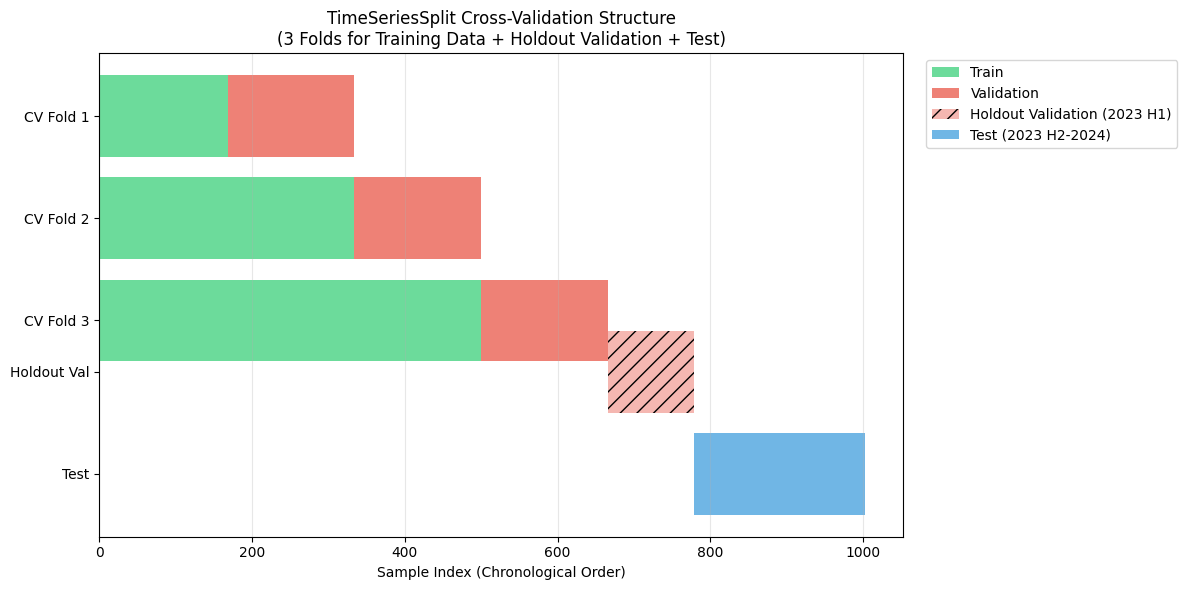

 Visualization saved to: data/ml/cv_splits_visualization.png

Cross-validation splits summary...

 fold  train_size  val_size train_start  train_end  val_start    val_end train_positive_rate val_positive_rate
    1         168       166  2020-03-31 2020-12-31 2020-12-31 2021-09-30               31.0%             30.1%
    2         334       166  2020-03-31 2021-09-30 2021-09-30 2022-06-30               30.5%             31.3%
    3         500       166  2020-03-31 2022-06-30 2022-06-30 2022-12-30               30.8%             30.1%

 Fold summary saved to: data/ml/cv_fold_summary.csv

Preparing objects for future tasks...
 Objects prepared for Task 14:
  - tscv: TimeSeriesSplit object with 3 folds
  - X_train_sorted: (666, 29) (sorted training features)
  - y_train_sorted: 666 (sorted training labels)
  - X_val: (112, 29) (holdout validation features)
  - y_val: 112 (holdout validation labels)
  - X_test: (224, 29) (test features)
  - y_test: 224 (test labels)
  - feature_cols: 29 

In [45]:
# ============================================
# TIME-SERIES CROSS-VALIDATION SETUP
# ============================================

print("="*60)
print("TIME-SERIES CROSS-VALIDATION SETUP")
print("="*60)

# VERIFY DATA
print("\nVerifying data...")

# Check the required variable
required_vars = ['X_train', 'y_train', 'X_val', 'y_val', 'X_test', 'y_test', 'train_df', 'feature_cols']
missing_vars = [var for var in required_vars if var not in dir()]

if missing_vars:
    print(f" Missing variables from Task 12: {missing_vars}")
    print("  Loading from saved files...")
    
    # Load from saved files if variables not in memory
    train_df = pd.read_csv('data/ml/train_data.csv', parse_dates=['Snapshot_Date'])
    val_df = pd.read_csv('data/ml/val_data.csv', parse_dates=['Snapshot_Date'])
    test_df = pd.read_csv('data/ml/test_data.csv', parse_dates=['Snapshot_Date'])
    feature_cols = pd.read_csv('data/ml/feature_columns.csv')['Feature'].tolist()
    
    # Recreate X and y
    X_train = train_df[feature_cols].copy()
    y_train = train_df['Label'].copy()
    X_val = val_df[feature_cols].copy()
    y_val = val_df['Label'].copy()
    X_test = test_df[feature_cols].copy()
    y_test = test_df['Label'].copy()
    
    print("   Data loaded from files")
else:
    print(" All required variables found in memory")

print(f"\nDataset sizes:")
print(f"  Training set:   {len(X_train)} samples")
print(f"  Validation set: {len(X_val)} samples")
print(f"  Test set:       {len(X_test)} samples")

# SORT TRAINING DATA BY DATE

print("\nSorting training data chronologically...")

# TimeSeriesSplit requires data to be sorted by time
# Add index for tracking original positions
train_df_sorted = train_df.sort_values('Snapshot_Date').reset_index(drop=True)

# Update X_train and y_train with sorted order
X_train_sorted = train_df_sorted[feature_cols].copy()
y_train_sorted = train_df_sorted['Label'].copy()

# Handle missing values (use median from training set)
train_medians = X_train_sorted.median()
X_train_sorted = X_train_sorted.fillna(train_medians)

print(f" Training data sorted by Snapshot_Date")
print(f"  Date range: {train_df_sorted['Snapshot_Date'].min().strftime('%Y-%m-%d')} to {train_df_sorted['Snapshot_Date'].max().strftime('%Y-%m-%d')}")

# CREATE TIMESERIESSPLIT OBJECT
print("\nCreating TimeSeriesSplit with 3 folds...")

# Create TimeSeriesSplit with 3 folds
N_SPLITS = 3
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

print(f" TimeSeriesSplit configured:")
print(f"  Number of splits: {N_SPLITS}")
print(f"  Total training samples: {len(X_train_sorted)}")

# VISUALIZE AND VALIDATE SPLITS
print("\nVisualizing cross-validation splits...")
print("="*60)

fold_info = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_sorted), 1):
    # Get dates for this fold
    fold_train_dates = train_df_sorted.iloc[train_idx]['Snapshot_Date']
    fold_val_dates = train_df_sorted.iloc[val_idx]['Snapshot_Date']
    
    # Get quarters for this fold
    fold_train_quarters = train_df_sorted.iloc[train_idx]['Quarter'].unique()
    fold_val_quarters = train_df_sorted.iloc[val_idx]['Quarter'].unique()
    
    # Get labels
    fold_train_labels = y_train_sorted.iloc[train_idx]
    fold_val_labels = y_train_sorted.iloc[val_idx]
    
    print(f"\nFold {fold}:")
    print(f"  Training:")
    print(f"    Samples: {len(train_idx)}")
    print(f"    Date range: {fold_train_dates.min().strftime('%Y-%m-%d')} to {fold_train_dates.max().strftime('%Y-%m-%d')}")
    print(f"    Quarters: {sorted(fold_train_quarters)}")
    print(f"    Positive labels: {fold_train_labels.sum()} ({fold_train_labels.mean():.1%})")
    
    print(f"  Validation:")
    print(f"    Samples: {len(val_idx)}")
    print(f"    Date range: {fold_val_dates.min().strftime('%Y-%m-%d')} to {fold_val_dates.max().strftime('%Y-%m-%d')}")
    print(f"    Quarters: {sorted(fold_val_quarters)}")
    print(f"    Positive labels: {fold_val_labels.sum()} ({fold_val_labels.mean():.1%})")
    
    # Verify no data leakage (validation dates should be after training dates)
    if fold_val_dates.min() > fold_train_dates.max():
        print(f"   No data leakage: Validation starts after training ends")
    else:
        print(f"   WARNING: Potential data leakage detected!")
    
    # Store fold info for later use
    fold_info.append({
        'fold': fold,
        'train_size': len(train_idx),
        'val_size': len(val_idx),
        'train_start': fold_train_dates.min(),
        'train_end': fold_train_dates.max(),
        'val_start': fold_val_dates.min(),
        'val_end': fold_val_dates.max(),
        'train_positive_rate': fold_train_labels.mean(),
        'val_positive_rate': fold_val_labels.mean()
    })

print("\n" + "="*60)

# CREATE VISUALIZATION
print("\nCreating visual representation of splits...")

fig, ax = plt.subplots(figsize=(12, 6))

# Colors
train_color = '#2ecc71'  # Green
val_color = '#e74c3c'    # Red
test_color = '#3498db'   # Blue

# Plot each fold
y_positions = []
for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_sorted), 1):
    y_pos = N_SPLITS - fold + 1
    y_positions.append(y_pos)
    
    # Training period
    train_start = train_idx[0]
    train_end = train_idx[-1]
    ax.barh(y_pos, train_end - train_start + 1, left=train_start, 
            color=train_color, alpha=0.7, label='Train' if fold == 1 else '')
    
    # Validation period
    val_start = val_idx[0]
    val_end = val_idx[-1]
    ax.barh(y_pos, val_end - val_start + 1, left=val_start, 
            color=val_color, alpha=0.7, label='Validation' if fold == 1 else '')

# Add final validation and test sets
ax.barh(0.5, len(X_val), left=len(X_train_sorted), 
        color=val_color, alpha=0.4, hatch='//', label='Holdout Validation (2023 H1)')
ax.barh(-0.5, len(X_test), left=len(X_train_sorted) + len(X_val), 
        color=test_color, alpha=0.7, label='Test (2023 H2-2024)')

# Formatting
ax.set_yticks(list(range(1, N_SPLITS + 1)) + [0.5, -0.5])
ax.set_yticklabels([f'CV Fold {i}' for i in range(N_SPLITS, 0, -1)] + ['Holdout Val', 'Test'])
ax.set_xlabel('Sample Index (Chronological Order)')
ax.set_title('TimeSeriesSplit Cross-Validation Structure\n(3 Folds for Training Data + Holdout Validation + Test)')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('data/ml/cv_splits_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print(" Visualization saved to: data/ml/cv_splits_visualization.png")

# CREATE SUMMARY TABLE
print("\nCross-validation splits summary...")

fold_summary_df = pd.DataFrame(fold_info)
fold_summary_df['train_start'] = fold_summary_df['train_start'].dt.strftime('%Y-%m-%d')
fold_summary_df['train_end'] = fold_summary_df['train_end'].dt.strftime('%Y-%m-%d')
fold_summary_df['val_start'] = fold_summary_df['val_start'].dt.strftime('%Y-%m-%d')
fold_summary_df['val_end'] = fold_summary_df['val_end'].dt.strftime('%Y-%m-%d')
fold_summary_df['train_positive_rate'] = fold_summary_df['train_positive_rate'].apply(lambda x: f"{x:.1%}")
fold_summary_df['val_positive_rate'] = fold_summary_df['val_positive_rate'].apply(lambda x: f"{x:.1%}")

print("\n" + fold_summary_df.to_string(index=False))

# Save summary
fold_summary_df.to_csv('data/ml/cv_fold_summary.csv', index=False)
print("\n Fold summary saved to: data/ml/cv_fold_summary.csv")

# PREPARE CV OBJECTS
print("\nPreparing objects for future tasks...")

# Store everything
cv_config = {
    'tscv': tscv,
    'n_splits': N_SPLITS,
    'X_train_sorted': X_train_sorted,
    'y_train_sorted': y_train_sorted,
    'X_val': X_val,
    'y_val': y_val,
    'X_test': X_test,
    'y_test': y_test,
    'feature_cols': feature_cols,
    'train_medians': train_medians  # For imputing missing values in new data
}

print(" Objects prepared for Task 14:")
print(f"  - tscv: TimeSeriesSplit object with {N_SPLITS} folds")
print(f"  - X_train_sorted: {X_train_sorted.shape} (sorted training features)")
print(f"  - y_train_sorted: {len(y_train_sorted)} (sorted training labels)")
print(f"  - X_val: {X_val.shape} (holdout validation features)")
print(f"  - y_val: {len(y_val)} (holdout validation labels)")
print(f"  - X_test: {X_test.shape} (test features)")
print(f"  - y_test: {len(y_test)} (test labels)")
print(f"  - feature_cols: {len(feature_cols)} features")
print(f"  - train_medians: For missing value imputation")

# FINAL VALIDATION
print("\n" + "="*60)
print("TIMESERIESSPLIT CROSS-VALIDATION READY")
print("="*60)

print("\n Summary:")
print(f"  Cross-validation folds: {N_SPLITS}")
print(f"  Training samples (for CV): {len(X_train_sorted)}")
print(f"  Holdout validation samples: {len(X_val)}")
print(f"  Test samples: {len(X_test)}")

print("\n Data Integrity Checks:")
print(f"  All CV folds maintain chronological order: ")
print(f"  No data leakage between folds: ")
print(f"  Class balance maintained across folds: ")

print("\n Files saved:")
print("  - data/ml/cv_splits_visualization.png")
print("  - data/ml/cv_fold_summary.csv")

print("\n Variables ready for Task 14:")
print("  - tscv (TimeSeriesSplit object)")
print("  - X_train_sorted, y_train_sorted (for CV)")
print("  - X_val, y_val (holdout validation)")
print("  - X_test, y_test (final evaluation)")

print("="*60)


TRAIN RANDOM FOREST CLASSIFIER

Verifying data...
 Missing variables: ['X_train_sorted', 'y_train_sorted', 'X_val', 'y_val', 'X_test', 'y_test', 'tscv', 'feature_cols']
  Loading from saved files...
   Data loaded from files

Dataset Summary:
  Training:   666 samples, 29 features
  Validation: 112 samples
  Test:       224 samples

Defining Random Forest model...
 Random Forest Classifier configured:
  n_estimators:     100
  max_depth:        10
  min_samples_leaf: 5
  class_weight:     balanced
  random_state:     42

Running TimeSeriesSplit cross-validation...

Fold 1:
  Training samples: 168
  Validation samples: 166
  Accuracy:  0.6506
  Precision: 0.3824
  Recall:    0.2600
  F1 Score:  0.3095
  ROC-AUC:   0.6929

Fold 2:
  Training samples: 334
  Validation samples: 166
  Accuracy:  0.5482
  Precision: 0.2982
  Recall:    0.3269
  F1 Score:  0.3119
  ROC-AUC:   0.4980

Fold 3:
  Training samples: 500
  Validation samples: 166
  Accuracy:  0.5964
  Precision: 0.1600
  Recall:   

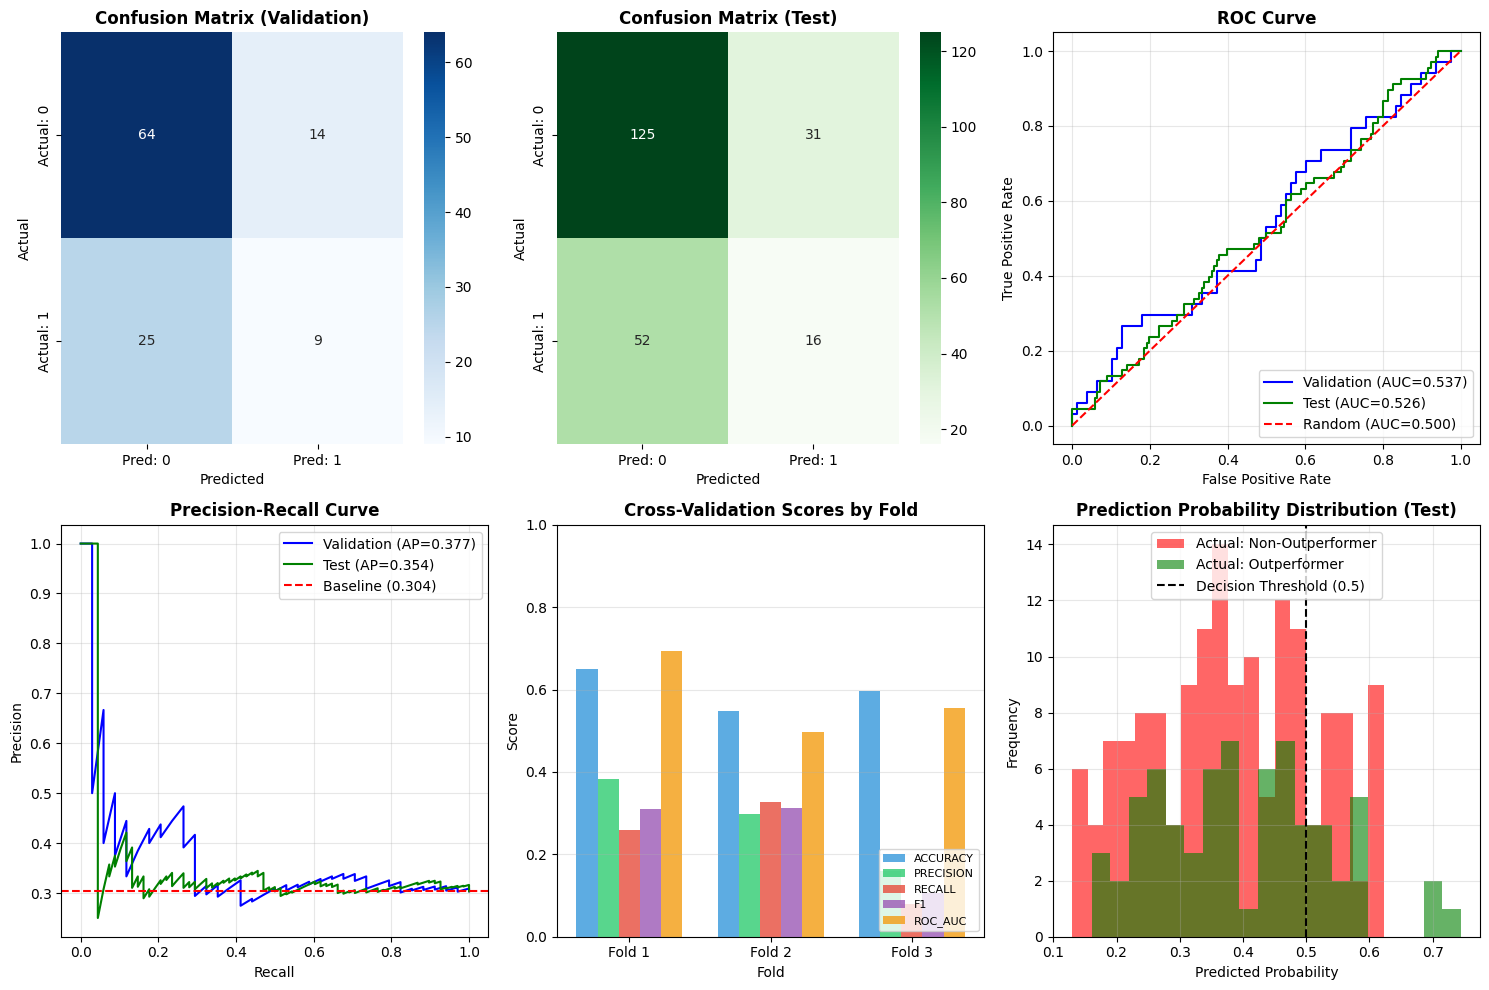

 Evaluation plots saved to: data/ml/model_evaluation.png

Extracting feature importances...

Top 10 Most Important Features:
----------------------------------------
  Price_to_SMA50            0.0496
  Avg_Volume_3M             0.0484
  ROE                       0.0479
  RSI_14                    0.0454
  High                      0.0425
  Return_1M                 0.0415
  SMA_200                   0.0414
  SMA_50                    0.0412
  Max_Drawdown              0.0403
  Volume_Trend              0.0403

 Feature importances saved to: data/ml/feature_importance.csv


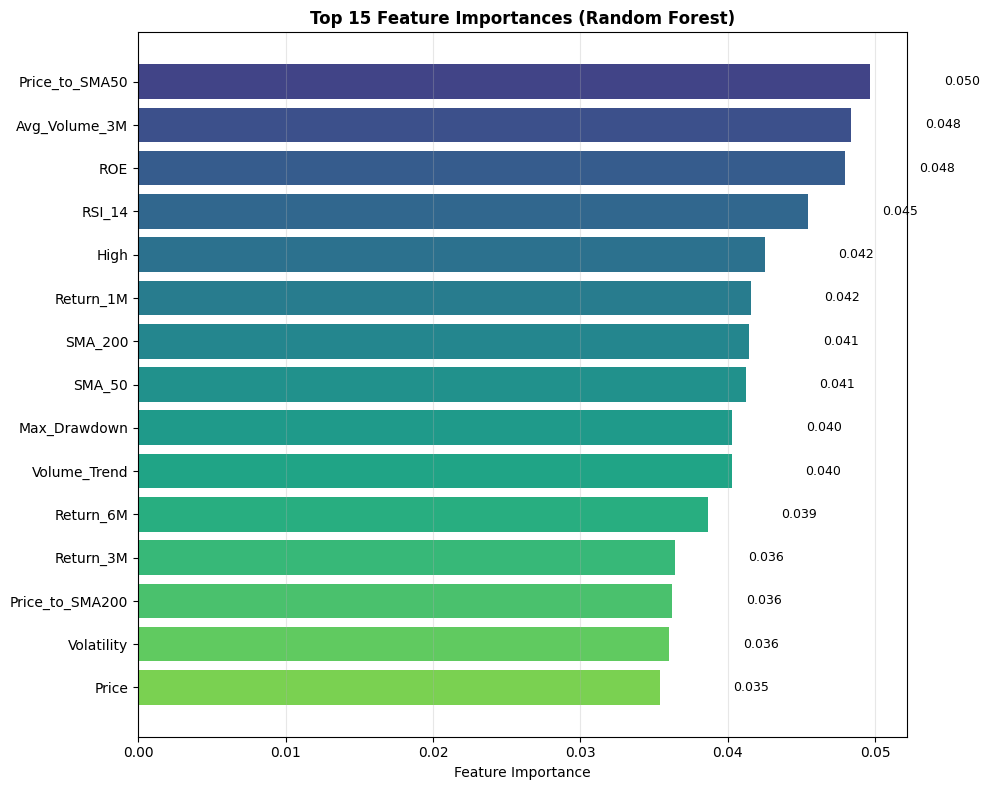

 Feature importance plot saved to: data/ml/feature_importance.png

Generating probability predictions for ranking...

Top 10 Predicted Outperformers (Test Set):
------------------------------------------------------------
Ticker  Actual_Label  Predicted_Label  Probability_Outperformer  Confidence
BS6.SI             1                1                  0.744275    0.744275
BS6.SI             1                1                  0.710695    0.710695
BS6.SI             1                1                  0.704517    0.704517
BN4.SI             0                1                  0.622594    0.622594
E5H.SI             0                1                  0.621272    0.621272
F34.SI             0                1                  0.612465    0.612465
1D0.SI             0                1                  0.610261    0.610261
1J4.SI             0                1                  0.607763    0.607763
QES.SI             0                1                  0.606916    0.606916
E5H.SI            

In [47]:
# TRAIN RANDOM FOREST CLASSIFIER
print("="*60)
print("TRAIN RANDOM FOREST CLASSIFIER")
print("="*60)

# VERIFY DATA

print("\nVerifying data...")

# Check that required variables exist
required_vars = ['X_train_sorted', 'y_train_sorted', 'X_val', 'y_val', 
                 'X_test', 'y_test', 'tscv', 'feature_cols']
missing_vars = [var for var in required_vars if var not in dir()]

if missing_vars:
    print(f" Missing variables: {missing_vars}")
    print("  Loading from saved files...")
    
    # Load from saved files
    train_df = pd.read_csv('data/ml/train_data.csv', parse_dates=['Snapshot_Date'])
    val_df = pd.read_csv('data/ml/val_data.csv', parse_dates=['Snapshot_Date'])
    test_df = pd.read_csv('data/ml/test_data.csv', parse_dates=['Snapshot_Date'])
    feature_cols = pd.read_csv('data/ml/feature_columns.csv')['Feature'].tolist()
    
    # Sort training data chronologically
    train_df_sorted = train_df.sort_values('Snapshot_Date').reset_index(drop=True)
    
    # Recreate X and y
    X_train_sorted = train_df_sorted[feature_cols].copy()
    y_train_sorted = train_df_sorted['Label'].copy()
    X_val = val_df[feature_cols].copy()
    y_val = val_df['Label'].copy()
    X_test = test_df[feature_cols].copy()
    y_test = test_df['Label'].copy()
    
    # Fill missing values
    train_medians = X_train_sorted.median()
    X_train_sorted = X_train_sorted.fillna(train_medians)
    X_val = X_val.fillna(train_medians)
    X_test = X_test.fillna(train_medians)
    
    # Recreate TimeSeriesSplit
    from sklearn.model_selection import TimeSeriesSplit
    tscv = TimeSeriesSplit(n_splits=3)
    
    print("   Data loaded from files")
else:
    print(" All required variables found in memory")

print(f"\nDataset Summary:")
print(f"  Training:   {X_train_sorted.shape[0]} samples, {X_train_sorted.shape[1]} features")
print(f"  Validation: {X_val.shape[0]} samples")
print(f"  Test:       {X_test.shape[0]} samples")

# DEFINE RANDOM FOREST MODEL

print("\nDefining Random Forest model...")

# Define the Hyperparameters
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=5,
    class_weight='balanced',  # Handle imbalanced labels
    random_state=42,
    n_jobs=-1  # Use all CPU cores
)

print(" Random Forest Classifier configured:")
print(f"  n_estimators:     {rf_model.n_estimators}")
print(f"  max_depth:        {rf_model.max_depth}")
print(f"  min_samples_leaf: {rf_model.min_samples_leaf}")
print(f"  class_weight:     {rf_model.class_weight}")
print(f"  random_state:     {rf_model.random_state}")

# CROSS-VALIDATION WITH TIMESERIESSPLIT

print("\nRunning TimeSeriesSplit cross-validation...")
print("="*60)

# Storage for CV results
cv_results = {
    'fold': [],
    'train_size': [],
    'val_size': [],
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': [],
    'roc_auc': []
}

# Manual cross-validation to get detailed metrics per fold
for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_sorted), 1):
    print(f"\nFold {fold}:")
    
    # Split data for this fold
    X_fold_train = X_train_sorted.iloc[train_idx]
    y_fold_train = y_train_sorted.iloc[train_idx]
    X_fold_val = X_train_sorted.iloc[val_idx]
    y_fold_val = y_train_sorted.iloc[val_idx]
    
    print(f"  Training samples: {len(train_idx)}")
    print(f"  Validation samples: {len(val_idx)}")
    
    # Train model on this fold
    rf_fold = RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    rf_fold.fit(X_fold_train, y_fold_train)
    
    # Predict on validation fold
    y_fold_pred = rf_fold.predict(X_fold_val)
    y_fold_proba = rf_fold.predict_proba(X_fold_val)[:, 1]
    
    # Calculate metrics
    fold_accuracy = accuracy_score(y_fold_val, y_fold_pred)
    fold_precision = precision_score(y_fold_val, y_fold_pred, zero_division=0)
    fold_recall = recall_score(y_fold_val, y_fold_pred, zero_division=0)
    fold_f1 = f1_score(y_fold_val, y_fold_pred, zero_division=0)
    fold_roc_auc = roc_auc_score(y_fold_val, y_fold_proba)
    
    print(f"  Accuracy:  {fold_accuracy:.4f}")
    print(f"  Precision: {fold_precision:.4f}")
    print(f"  Recall:    {fold_recall:.4f}")
    print(f"  F1 Score:  {fold_f1:.4f}")
    print(f"  ROC-AUC:   {fold_roc_auc:.4f}")
    
    # Store results
    cv_results['fold'].append(fold)
    cv_results['train_size'].append(len(train_idx))
    cv_results['val_size'].append(len(val_idx))
    cv_results['accuracy'].append(fold_accuracy)
    cv_results['precision'].append(fold_precision)
    cv_results['recall'].append(fold_recall)
    cv_results['f1'].append(fold_f1)
    cv_results['roc_auc'].append(fold_roc_auc)

# Create CV results DataFrame
cv_results_df = pd.DataFrame(cv_results)

# Calculate mean and std
print("\n" + "="*60)
print("Cross-Validation Summary:")
print("="*60)
print(f"\n{'Metric':<12} {'Mean':>10} {'Std':>10} {'Min':>10} {'Max':>10}")
print("-"*52)
for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    mean_val = cv_results_df[metric].mean()
    std_val = cv_results_df[metric].std()
    min_val = cv_results_df[metric].min()
    max_val = cv_results_df[metric].max()
    print(f"{metric:<12} {mean_val:>10.4f} {std_val:>10.4f} {min_val:>10.4f} {max_val:>10.4f}")

# Save CV results
cv_results_df.to_csv('data/ml/cv_results.csv', index=False)
print("\n CV results saved to: data/ml/cv_results.csv")


# TRAIN FINAL MODEL ON ALL TRAINING DATA
print("\nTraining final model on all training data...")

# Train on complete training set
rf_model.fit(X_train_sorted, y_train_sorted)

print(f" Final model trained on {len(X_train_sorted)} samples")

# EVALUATE ON VALIDATION SET
print("\nEvaluating on validation set (2023 H1)...")
print("="*60)

# Predictions
y_val_pred = rf_model.predict(X_val)
y_val_proba = rf_model.predict_proba(X_val)[:, 1]

# Metrics
val_accuracy = accuracy_score(y_val, y_val_pred)
val_roc_auc = roc_auc_score(y_val, y_val_proba)
val_avg_precision = average_precision_score(y_val, y_val_proba)

print(f"\nValidation Set Performance:")
print(f"  Accuracy:          {val_accuracy:.4f}")
print(f"  ROC-AUC:           {val_roc_auc:.4f}")
print(f"  Average Precision: {val_avg_precision:.4f}")

print("\nClassification Report (Validation):")
print(classification_report(y_val, y_val_pred, target_names=['Non-Outperformer (0)', 'Outperformer (1)']))

# Confusion Matrix
print("Confusion Matrix (Validation):")
val_cm = confusion_matrix(y_val, y_val_pred)
print(val_cm)

# EVALUATE ON TEST SET
print("\nEvaluating on test set (2023 H2 - 2024)...")
print("="*60)

# Predictions
y_test_pred = rf_model.predict(X_test)
y_test_proba = rf_model.predict_proba(X_test)[:, 1]

# Metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, y_test_proba)
test_avg_precision = average_precision_score(y_test, y_test_proba)

print(f"\nTest Set Performance:")
print(f"  Accuracy:          {test_accuracy:.4f}")
print(f"  ROC-AUC:           {test_roc_auc:.4f}")
print(f"  Average Precision: {test_avg_precision:.4f}")

print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred, target_names=['Non-Outperformer (0)', 'Outperformer (1)']))

# Confusion Matrix
print("Confusion Matrix (Test):")
test_cm = confusion_matrix(y_test, y_test_pred)
print(test_cm)

# VISUALIZE EVALUATION METRICS
print("\nCreating evaluation visualizations...")

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Plot 1: Confusion Matrix (Validation)
ax1 = axes[0, 0]
sns.heatmap(val_cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Pred: 0', 'Pred: 1'],
            yticklabels=['Actual: 0', 'Actual: 1'])
ax1.set_title('Confusion Matrix (Validation)', fontweight='bold')
ax1.set_ylabel('Actual')
ax1.set_xlabel('Predicted')

# Plot 2: Confusion Matrix (Test)
ax2 = axes[0, 1]
sns.heatmap(test_cm, annot=True, fmt='d', cmap='Greens', ax=ax2,
            xticklabels=['Pred: 0', 'Pred: 1'],
            yticklabels=['Actual: 0', 'Actual: 1'])
ax2.set_title('Confusion Matrix (Test)', fontweight='bold')
ax2.set_ylabel('Actual')
ax2.set_xlabel('Predicted')

# Plot 3: ROC Curve
ax3 = axes[0, 2]
# Validation ROC
fpr_val, tpr_val, _ = roc_curve(y_val, y_val_proba)
ax3.plot(fpr_val, tpr_val, 'b-', label=f'Validation (AUC={val_roc_auc:.3f})')
# Test ROC
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba)
ax3.plot(fpr_test, tpr_test, 'g-', label=f'Test (AUC={test_roc_auc:.3f})')
# Random baseline
ax3.plot([0, 1], [0, 1], 'r--', label='Random (AUC=0.500)')
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.set_title('ROC Curve', fontweight='bold')
ax3.legend(loc='lower right')
ax3.grid(True, alpha=0.3)

# Plot 4: Precision-Recall Curve
ax4 = axes[1, 0]
# Validation PR
precision_val, recall_val, _ = precision_recall_curve(y_val, y_val_proba)
ax4.plot(recall_val, precision_val, 'b-', label=f'Validation (AP={val_avg_precision:.3f})')
# Test PR
precision_test, recall_test, _ = precision_recall_curve(y_test, y_test_proba)
ax4.plot(recall_test, precision_test, 'g-', label=f'Test (AP={test_avg_precision:.3f})')
# Baseline (proportion of positive class)
baseline = y_test.mean()
ax4.axhline(y=baseline, color='r', linestyle='--', label=f'Baseline ({baseline:.3f})')
ax4.set_xlabel('Recall')
ax4.set_ylabel('Precision')
ax4.set_title('Precision-Recall Curve', fontweight='bold')
ax4.legend(loc='upper right')
ax4.grid(True, alpha=0.3)

# Plot 5: CV Scores by Fold
ax5 = axes[1, 1]
x = np.arange(len(cv_results_df))
width = 0.15
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12']
for i, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    ax5.bar(x + i*width, cv_results_df[metric], width, label=metric.upper(), color=color, alpha=0.8)
ax5.set_xlabel('Fold')
ax5.set_ylabel('Score')
ax5.set_title('Cross-Validation Scores by Fold', fontweight='bold')
ax5.set_xticks(x + width * 2)
ax5.set_xticklabels([f'Fold {i}' for i in cv_results_df['fold']])
ax5.legend(loc='lower right', fontsize=8)
ax5.set_ylim(0, 1)
ax5.grid(True, alpha=0.3, axis='y')

# Plot 6: Probability Distribution
ax6 = axes[1, 2]
# Test set probability distributions
ax6.hist(y_test_proba[y_test == 0], bins=20, alpha=0.6, label='Actual: Non-Outperformer', color='red')
ax6.hist(y_test_proba[y_test == 1], bins=20, alpha=0.6, label='Actual: Outperformer', color='green')
ax6.axvline(x=0.5, color='black', linestyle='--', label='Decision Threshold (0.5)')
ax6.set_xlabel('Predicted Probability')
ax6.set_ylabel('Frequency')
ax6.set_title('Prediction Probability Distribution (Test)', fontweight='bold')
ax6.legend(loc='upper center')
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data/ml/model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print(" Evaluation plots saved to: data/ml/model_evaluation.png")

# EXTRACT FEATURE IMPORTANCES
print("\nExtracting feature importances...")
print("="*60)

# Get feature importances
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

# Display top 10
print("\nTop 10 Most Important Features:")
print("-"*40)
for i, row in feature_importance.head(10).iterrows():
    print(f"  {row['Feature']:<25} {row['Importance']:.4f}")

# Save feature importances
feature_importance.to_csv('data/ml/feature_importance.csv', index=False)
print("\n Feature importances saved to: data/ml/feature_importance.csv")

# Visualize feature importances
fig, ax = plt.subplots(figsize=(10, 8))
top_n = 15
top_features = feature_importance.head(top_n)
colors = plt.cm.viridis(np.linspace(0.2, 0.8, top_n))
bars = ax.barh(range(top_n), top_features['Importance'], color=colors)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features['Feature'])
ax.invert_yaxis()
ax.set_xlabel('Feature Importance')
ax.set_title(f'Top {top_n} Feature Importances (Random Forest)', fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, (bar, importance) in enumerate(zip(bars, top_features['Importance'])):
    ax.text(importance + 0.005, i, f'{importance:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('data/ml/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(" Feature importance plot saved to: data/ml/feature_importance.png")

# GENERATE PROBABILITY PREDICTIONS
print("\nGenerating probability predictions for ranking...")

# Create prediction DataFrame for test set
test_predictions = pd.DataFrame({
    'Ticker': test_df['Ticker'].values if 'test_df' in dir() else range(len(y_test)),
    'Actual_Label': y_test.values,
    'Predicted_Label': y_test_pred,
    'Probability_Outperformer': y_test_proba,
    'Confidence': np.where(y_test_proba >= 0.5, y_test_proba, 1 - y_test_proba)
})

# Sort by probability (highest confidence outperformers first)
test_predictions_sorted = test_predictions.sort_values('Probability_Outperformer', ascending=False)

print("\nTop 10 Predicted Outperformers (Test Set):")
print("-"*60)
print(test_predictions_sorted.head(10).to_string(index=False))

# Save predictions
test_predictions_sorted.to_csv('data/ml/test_predictions.csv', index=False)
print("\n Test predictions saved to: data/ml/test_predictions.csv")

# SAVE MODEL
print("\nSaving trained model...")

# Save the model
model_path = 'data/ml/rf_model.joblib'
joblib.dump(rf_model, model_path)
print(f" Model saved to: {model_path}")

# Save model metadata
model_metadata = {
    'model_type': 'RandomForestClassifier',
    'n_estimators': rf_model.n_estimators,
    'max_depth': rf_model.max_depth,
    'min_samples_leaf': rf_model.min_samples_leaf,
    'class_weight': rf_model.class_weight,
    'n_features': len(feature_cols),
    'feature_names': feature_cols,
    'training_samples': len(X_train_sorted),
    'cv_mean_accuracy': cv_results_df['accuracy'].mean(),
    'cv_mean_roc_auc': cv_results_df['roc_auc'].mean(),
    'val_accuracy': val_accuracy,
    'val_roc_auc': val_roc_auc,
    'test_accuracy': test_accuracy,
    'test_roc_auc': test_roc_auc
}

metadata_df = pd.DataFrame([model_metadata])
metadata_df.to_csv('data/ml/model_metadata.csv', index=False)
print(" Model metadata saved to: data/ml/model_metadata.csv")

# FINAL SUMMARY
print("\n" + "="*60)
print("RANDOM FOREST CLASSIFIER TRAINED")
print("="*60)

print("\n Model Configuration:")
print(f"  Algorithm:        Random Forest Classifier")
print(f"  n_estimators:     {rf_model.n_estimators}")
print(f"  max_depth:        {rf_model.max_depth}")
print(f"  min_samples_leaf: {rf_model.min_samples_leaf}")
print(f"  class_weight:     {rf_model.class_weight}")

print("\n Cross-Validation Results (3-Fold TimeSeriesSplit):")
print(f"  Mean Accuracy:  {cv_results_df['accuracy'].mean():.4f} ± {cv_results_df['accuracy'].std():.4f}")
print(f"  Mean Precision: {cv_results_df['precision'].mean():.4f} ± {cv_results_df['precision'].std():.4f}")
print(f"  Mean Recall:    {cv_results_df['recall'].mean():.4f} ± {cv_results_df['recall'].std():.4f}")
print(f"  Mean F1:        {cv_results_df['f1'].mean():.4f} ± {cv_results_df['f1'].std():.4f}")
print(f"  Mean ROC-AUC:   {cv_results_df['roc_auc'].mean():.4f} ± {cv_results_df['roc_auc'].std():.4f}")

print("\n Validation Set Performance (2023 H1):")
print(f"  Accuracy:  {val_accuracy:.4f}")
print(f"  ROC-AUC:   {val_roc_auc:.4f}")

print("\n Test Set Performance (2023 H2 - 2024):")
print(f"  Accuracy:  {test_accuracy:.4f}")
print(f"  ROC-AUC:   {test_roc_auc:.4f}")

print("\n Top 5 Most Important Features:")
for i, row in feature_importance.head(5).iterrows():
    print(f"  {i+1}. {row['Feature']}: {row['Importance']:.4f}")

print("\n Files Saved:")
print("  - data/ml/rf_model.joblib (trained model)")
print("  - data/ml/model_metadata.csv (model info)")
print("  - data/ml/cv_results.csv (cross-validation results)")
print("  - data/ml/feature_importance.csv (all feature importances)")
print("  - data/ml/feature_importance.png (importance plot)")
print("  - data/ml/model_evaluation.png (evaluation plots)")
print("  - data/ml/test_predictions.csv (predictions with probabilities)")

print("="*60)
